### Autoreload

Autoreload allows the notebook to dynamically load code: if we update some helper functions *outside* of the notebook, we do not need to reload the notebook.

In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
# All auxiliary code is in ../src

import sys

sys.path.append("../src/")

As first thing we imported all the necessary modules.

In [81]:
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
from scipy.stats import entropy

Dataset loading

In [82]:
races = pd.read_csv('../dataset/races.csv', sep=",")
imputed_cyclists = pd.read_csv('../dataset/preprocessedCyclists.csv', sep=",")
cyclists = pd.read_csv('../dataset/cyclists.csv', sep=",")
races_pre_imputation=races.copy()

## New feature (lenght/climb total)

In [83]:
races.columns

Index(['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'date',
       'position', 'cyclist', 'cyclist_age', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'cyclist_team', 'delta'],
      dtype='object')

In [84]:
races['climb/length'] = races['climb_total'] / races['length']

In [85]:
from distribution_utility import stats_and_distribution, show_stats, calculate_outlier_bounds

In [86]:
#extraction of features related to the race and not to the placement
cyclist_races_columns = ['position', 'cyclist', 'cyclist_age', 'cyclist_team', 'delta', 'date'] #date should be discarded since it's the arrival time
races_columns = [col for col in races.columns if col not in cyclist_races_columns]

#races_data will contain all the 'events' in the dataset with their specific information
races_data = races.drop_duplicates(subset=races_columns)[races_columns].reset_index(drop=True)
races_data_pre_imputation=races_data.copy()
races_data

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
0,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,True,False,False,0.006796
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80.0,100.0,196000.0,5575.0,5.0,821,NaN,True,False,False,0.028444
2,tour-de-france/2019/stage-21,Tour de France,100.0,120.0,128000.0,781.0,1.0,1699,NaN,True,False,False,0.006102
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50.0,NaN,8100.0,NaN,NaN,804,NaN,True,False,False,NaN
4,tour-de-france/2022/stage-9,Tour de France,100.0,120.0,192900.0,3743.0,3.0,1551,24.0,True,False,False,0.019404
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5276,giro-d-italia/2017/stage-3,Giro d'Italia,80.0,100.0,148000.0,1441.0,1.0,881,NaN,True,False,False,0.009736
5277,paris-roubaix/2000/result,Paris - Roubaix,275.0,NaN,273000.0,NaN,1.0,808,NaN,False,False,False,NaN
5278,paris-nice/1976/stage-2,Paris - Nice,50.0,NaN,185000.0,NaN,NaN,779,NaN,True,False,False,NaN
5279,volta-a-catalunya/2016/stage-7,Volta Ciclista a Catalunya,50.0,50.0,136400.0,1880.0,2.0,1045,NaN,True,False,False,0.013783


In [87]:
races_data['climb/length'] = races_data['climb_total'] / races_data['length']

Description of attribute 'climb/length':


count    3067.000000
mean        0.014813
std         0.009059
min         0.000069
25%         0.008803
50%         0.013438
75%         0.018845
max         0.103261
Name: climb/length, dtype: float64


Unique values:
[0.0067963  0.02844388 0.00610156 ... 0.00973649 0.01378299 0.00714286]

Null values: 2214 over 5281 records - (41.92%)

Top 5 common value:
climb/length
0.012440    3
0.029570    3
0.007500    3
0.012376    3
0.015437    2
Name: count, dtype: int64


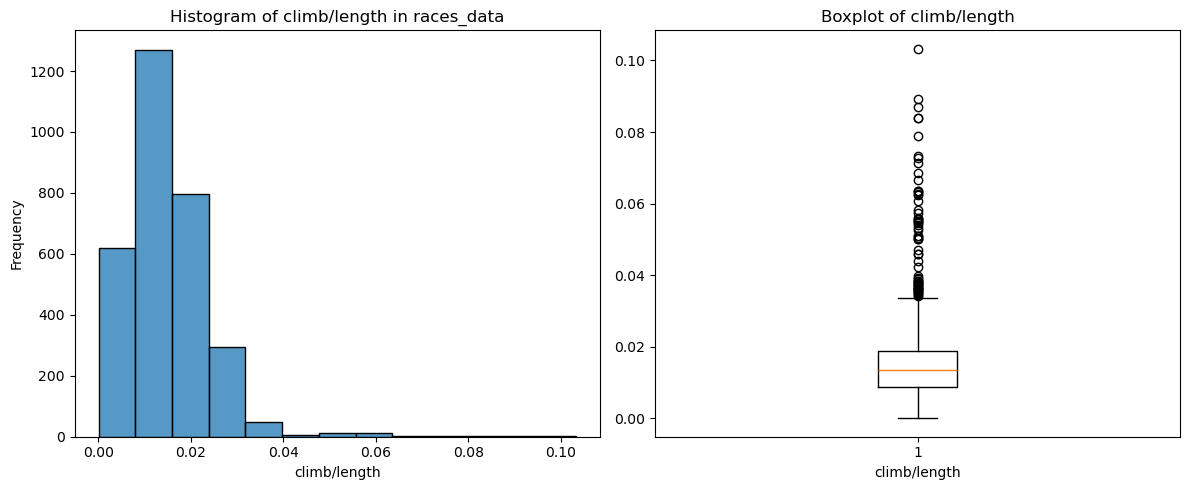

Outliers in climb/length: [0.0625, 0.05580808080808081, 0.03835294117647059, 0.06345833333333334, 0.07268518518518519, 0.05023648648648649, 0.03691275167785235, 0.05395833333333333, 0.05271844660194175, 0.05446575342465754, 0.035765217391304345, 0.0352415210688592, 0.056, 0.03459119496855346, 0.05322916666666667, 0.036375, 0.03806363636363636, 0.03423423423423423, 0.035515151515151513, 0.034926470588235295, 0.03725641025641026, 0.03976470588235294, 0.03772350230414746, 0.044, 0.05821875, 0.05023157894736842, 0.06075313807531381, 0.046052631578947366, 0.05101639344262295, 0.04709090909090909, 0.03624503311258278, 0.04594285714285714, 0.05489583333333333, 0.037445378151260506, 0.07126666666666667, 0.06674074074074074, 0.03928260869565217, 0.05514619883040936, 0.057526881720430106, 0.03906040268456376, 0.087, 0.042339181286549704, 0.034957627118644065, 0.036417910447761194, 0.05092783505154639, 0.036565371024734984, 0.03723684210526316, 0.036036036036036036, 0.06264925373134328, 0.0686875

In [88]:
stats_and_distribution(races_data, 'climb/length', attr_type='numerical')

We can observe that the distribution presents a positive skew with a long tail. This means that most of the races have small a climb/length ratio, in particular the climb part of a race event is typically <4%. The boxplot classifies as outliers all the races with a ratio grater than 2.85%. Notice that there is a single race event with an uphill portion of that constitutes 10% of the total distance.

In [89]:
iqr=(races_data['climb/length'].quantile(0.75))-(races_data['climb/length'].quantile(0.25))
print(f"Upper wisker limit: {races_data['climb/length'].quantile(0.5)+1.5*iqr}")

Upper wisker limit: 0.028501854042755605


In [90]:
races_data[races_data['climb/length']==0.10326086956521739]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
1144,tour-de-france/1996/stage-9,Tour de France,100.0,NaN,46000.0,4750.0,5.0,1872,NaN,True,False,False,0.103261


In [91]:
print(f"Correlation between climb/length and profile: {races_data['climb/length'].corr(races_data['profile'], method='kendall')}")
print(f"Correlation between climb and profile: {races_data['climb_total'].corr(races_data['profile'], method='kendall')}")
print(f"Correlation between length and profile: {races_data['length'].corr(races_data['profile'], method='kendall')}")

Correlation between climb/length and profile: 0.6251513605040532
Correlation between climb and profile: 0.572520132871134
Correlation between length and profile: 0.006155688405006674


As shown by the Kendall scores, which is the best metric for assessing correlation with a rank attribute, using the ratio climb/length has increased the correlation with the ordinal feature 'profile' compared to just looking at the 'climb_total' value.

In [92]:
def correlations(dataset: pd.DataFrame) -> pd.DataFrame:
    correlations_dictionary = {
        correlation_type: dataset.corr(numeric_only=True, method=correlation_type)
        for correlation_type in ("kendall", "pearson", "spearman")
    }
    for i, k in enumerate(correlations_dictionary.keys()):
        correlations_dictionary[k].loc[:, "correlation_type"] = k
    correlations_matrix = pd.concat(correlations_dictionary.values())

    return correlations_matrix

In [93]:
correlation_matrix_races_data=correlations(races_data)
correlation_matrix_races_data

,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length,correlation_type
points,1.000000,0.514667,0.327285,0.062379,-0.103855,0.346395,0.118070,-0.514144,NaN,NaN,-0.047898,kendall
uci_points,0.514667,1.000000,0.130646,0.058834,-0.010730,-0.008093,0.040138,-0.378570,NaN,NaN,-0.007390,kendall
length,0.327285,0.130646,1.000000,0.296914,0.006156,0.047565,-0.095148,-0.388565,NaN,NaN,-0.077612,kendall
climb_total,0.062379,0.058834,0.296914,1.000000,0.572520,0.009008,-0.080778,-0.111602,NaN,NaN,0.626271,kendall
profile,-0.103855,-0.010730,0.006156,0.572520,1.000000,-0.076665,-0.013459,0.052719,NaN,NaN,0.625151,kendall
startlist_quality,0.346395,-0.008093,0.047565,0.009008,-0.076665,1.000000,0.205643,0.114783,NaN,NaN,-0.015020,kendall
average_temperature,0.118070,0.040138,-0.095148,-0.080778,-0.013459,0.205643,1.000000,0.235771,NaN,NaN,-0.048647,kendall
is_tarmac,-0.514144,-0.378570,-0.388565,-0.111602,0.052719,0.114783,0.235771,1.000000,NaN,NaN,0.034305,kendall
is_cobbled,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,kendall
is_gravel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,kendall


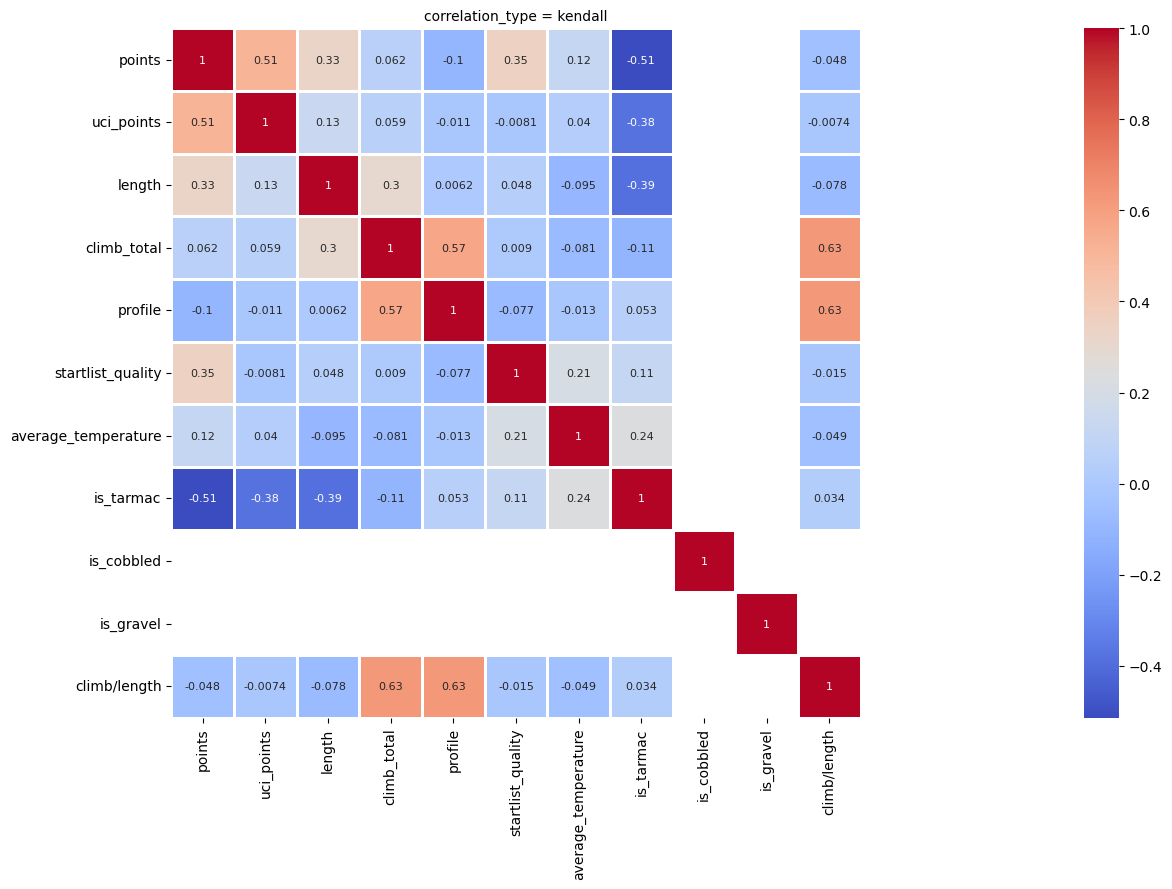

In [94]:
only_pearson=correlation_matrix_races_data[correlation_matrix_races_data['correlation_type'] == 'kendall']
g = sbn.FacetGrid(only_pearson, col="correlation_type", col_wrap=1, height=9, aspect=5)
g.map_dataframe(lambda data, color: sbn.heatmap(
    data[data.columns[:-1]], #Ignore the last column of the matrix which contains the correlation type
    cmap="coolwarm", #Colormap 
    annot=True, #Correlation values inside the cell
    square=True, #Square shape for each cell of the matrix
    cbar=True, #Color bar next to the matrix to "visually" interpret the correlation
    linewidths=1,  #Lines between cells
    annot_kws={"size": 8}  #Font size
))
plt.show()
plt.close()

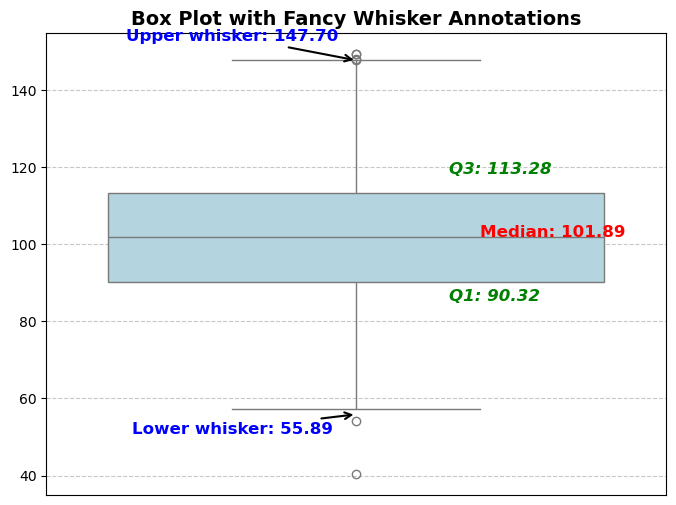

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generate example data
np.random.seed(10)
data = np.random.normal(100, 20, 200)

# Create a box plot
plt.figure(figsize=(8, 6))
box_plot = sns.boxplot(data=data, color="lightblue")

# Calculate statistics for the box plot (Q1, Q3, whiskers)
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1  # Interquartile range
median = np.percentile(data, 50)

# Calculate whiskers
lower_whisker = max(min(data), q1 - 1.5 * iqr)
upper_whisker = min(max(data), q3 + 1.5 * iqr)

# Annotate whiskers with arrows and styled text
plt.annotate(f'Lower whisker: {lower_whisker:.2f}',
             xy=(0, lower_whisker), xytext=(-0.2, lower_whisker - 5),
             arrowprops=dict(facecolor='blue', arrowstyle="->", lw=1.5),
             ha='center', color='blue', fontsize=12, fontweight='bold')

plt.annotate(f'Upper whisker: {upper_whisker:.2f}',
             xy=(0, upper_whisker), xytext=(-0.2, upper_whisker + 5),
             arrowprops=dict(facecolor='blue', arrowstyle="->", lw=1.5),
             ha='center', color='blue', fontsize=12, fontweight='bold')

# Annotate Q1, Q3, and Median with styled text
plt.annotate(f'Q1: {q1:.2f}', xy=(0, q1), xytext=(0.15, q1 - 5),
             color='green', fontsize=12, fontstyle='italic', fontweight='bold')
plt.annotate(f'Q3: {q3:.2f}', xy=(0, q3), xytext=(0.15, q3 + 5),
             color='green', fontsize=12, fontstyle='italic', fontweight='bold')
plt.annotate(f'Median: {median:.2f}', xy=(0, median), xytext=(0.2, median),
             color='red', fontsize=12, fontweight='bold')

# Customize plot aesthetics
plt.title("Box Plot with Fancy Whisker Annotations", fontsize=14, fontweight='bold')
plt.xticks([])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()


In [96]:
nrec = races.shape[0]
results = {
    'Feature': [],
    'Null_counter': [],
    'Perc_of_null_(%)': []
}

for col in races.columns:
    nanCount = races[col].isna().sum()
    perc = round((nanCount*100)/nrec,1)
    results['Feature'].append(col)
    results['Null_counter'].append(nanCount)
    results['Perc_of_null_(%)'].append(perc)

df_results = pd.DataFrame(results)

display(df_results)

,Feature,Null_counter,Perc_of_null_(%)
0,_url,0,0.0
1,name,0,0.0
2,points,477,0.1
3,uci_points,338779,57.4
4,length,0,0.0
5,climb_total,147045,24.9
6,profile,148194,25.1
7,startlist_quality,0,0.0
8,average_temperature,559932,94.9
9,date,0,0.0


## Points imputation

In [97]:
races_data[races_data['points'].isna()]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
1423,vuelta-a-espana/1994/stage-5,Vuelta a España,NaN,NaN,166900.0,1547.0,NaN,791,NaN,True,False,False,0.009269
4167,tour-de-france/1986/stage-19,Tour de France,NaN,NaN,179500.0,3000.0,4.0,1872,NaN,True,False,False,0.016713
4661,tour-de-france/1988/prologue,Tour de France,NaN,NaN,1000.0,44.0,1.0,1941,NaN,True,False,False,0.044000
5035,tour-de-france/2019/stage-19,Tour de France,NaN,NaN,89000.0,2995.0,5.0,1699,NaN,True,False,False,0.033652


As we can see there are only 4 race events for which we have not the point reference. Let's see again which 'points' are typically assigned to a race; we expect them to be to assume values in a defined set/range.

In [98]:
points_set=np.sort(races_data['points'].unique())
points_set

array([ 18.,  20.,  30.,  35.,  50.,  70.,  75.,  80., 100., 125., 150.,
       225., 275., 350.,  nan])

In [99]:
tdf_no_points=races_data[races_data['_url'].str.contains(r'tour-de-france/\d{4}/stage-19', regex=True)].sort_values(by="_url")
tdf_no_points

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
230,tour-de-france/1978/stage-19,Tour de France,100.0,NaN,182000.0,2000.0,2.0,1241,NaN,True,False,False,0.010989
334,tour-de-france/1979/stage-19,Tour de France,100.0,NaN,162000.0,1568.0,2.0,1381,NaN,True,False,False,0.009679
1927,tour-de-france/1980/stage-19,Tour de France,100.0,NaN,136500.0,2439.0,4.0,1224,NaN,True,False,False,0.017868
971,tour-de-france/1981/stage-19,Tour de France,100.0,NaN,117500.0,1996.0,2.0,1362,NaN,True,False,False,0.016987
5055,tour-de-france/1982/stage-19,Tour de France,100.0,NaN,48000.0,508.0,2.0,1492,NaN,True,False,False,0.010583
1310,tour-de-france/1983/stage-19,Tour de France,100.0,NaN,15000.0,1069.0,5.0,1269,NaN,True,False,False,0.071267
913,tour-de-france/1984/stage-19,Tour de France,100.0,NaN,186000.0,5500.0,4.0,1632,NaN,True,False,False,0.029570
3530,tour-de-france/1985/stage-19,Tour de France,100.0,NaN,200000.0,1637.0,1.0,1470,NaN,True,False,False,0.008185
4167,tour-de-france/1986/stage-19,Tour de France,NaN,NaN,179500.0,3000.0,4.0,1872,NaN,True,False,False,0.016713
1770,tour-de-france/1987/stage-19,Tour de France,100.0,NaN,185000.0,4842.0,4.0,1812,NaN,True,False,False,0.026173


In [100]:
tour_de_france_df = races_data[races_data['_url'].str.startswith('tour-de-france')]
tour_de_france_df['points'].value_counts(normalize=True)

points
100.0    0.975771
70.0     0.023128
50.0     0.001101
Name: proportion, dtype: float64

We can observe that 97% of the stages of the "Tour de France" have a score of 100. Since the scores are "drawn" from a specific set, as already told before, it's reasonable to assign the score 100 to the 3 stages of the "Tour de France" with a NaN reference.

In [101]:
rows_to_fill = races_data[(races_data['_url'].str.startswith('tour-de-france'))&(races_data['points'].isna())]
rows_to_fill

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
4167,tour-de-france/1986/stage-19,Tour de France,NaN,NaN,179500.0,3000.0,4.0,1872,NaN,True,False,False,0.016713
4661,tour-de-france/1988/prologue,Tour de France,NaN,NaN,1000.0,44.0,1.0,1941,NaN,True,False,False,0.044000
5035,tour-de-france/2019/stage-19,Tour de France,NaN,NaN,89000.0,2995.0,5.0,1699,NaN,True,False,False,0.033652


In [102]:
rows_to_fill.loc[:, 'points'] = rows_to_fill['points'].fillna(100)
races_data.update(rows_to_fill) #update the dataframe which still have NaNs

In [103]:
races_data[races_data['points'].isna()]


,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length
1423,vuelta-a-espana/1994/stage-5,Vuelta a España,NaN,NaN,166900.0,1547.0,NaN,791,NaN,True,False,False,0.009269


In [104]:
vae_no_points=races_data[races_data['_url'].str.startswith('vuelta-a-espana')]
vae_no_points['points'].value_counts(normalize=True)

points
80.0    0.996641
50.0    0.003359
Name: proportion, dtype: float64

Since 99% of the race events related to '_vuelta-a-espana_' have a score of 80, we decide to impute the only stage with a NaN using this value.

In [105]:
rows_to_fill = races_data[(races_data['_url'].str.startswith('vuelta-a-espana'))&(races_data['points'].isna())]
rows_to_fill.loc[:, 'points'] = rows_to_fill['points'].fillna(80)
races_data.update(rows_to_fill) #update the dataframe which still have NaNs

In [106]:
races_data[races_data['points'].isna()]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length


In [107]:
def imputationComparison(original_df, imputed_df, column):
    #Two plots in the same row
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sbn.histplot(original_df, x=column, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of "{column}" pre-imputation')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')

    sbn.histplot(imputed_df, x=column, ax=axes[1], kde=True)
    axes[1].set_title(f'Histogram of "{column}" after-imputation')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
    plt.close()

    plt.figure(figsize=(8, 6))

    #Unique boxplot with multiple datasets representing the initial situation and the imputation strategies
    plt.boxplot(
        [original_df[column].dropna(), imputed_df[column]],
        labels=['Pre-Imputation', 'After Imputation']
    )
    plt.title(f"Boxplot of {column} before and after the imputation phase")
    plt.ylabel(column)
    plt.show()
    plt.close()

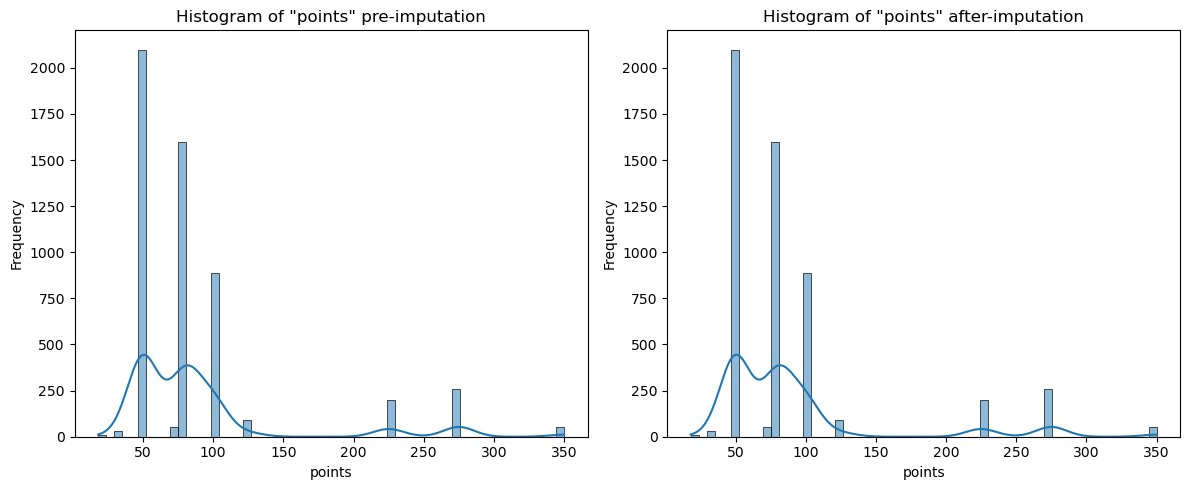

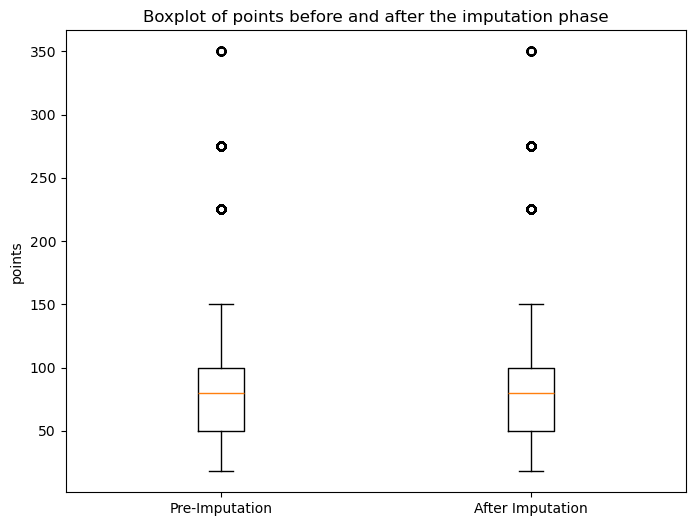

In [108]:
imputationComparison(races_data_pre_imputation, races_data, 'points')

Since we have operated on few races. 

## Cyclist age (& Birth year)

In [109]:
cyclists.columns

Index(['_url', 'name', 'birth_year', 'weight', 'height', 'nationality'], dtype='object')

In [110]:
imputed_cyclists.columns

Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'nationality', 'continent', 'geo area', 'birth_year',
       'AVG weighted position', 'AVG position Autumn', 'AVG position Spring',
       'AVG position Summer', 'AVG position Winter', 'AVG position Q1',
       'AVG position Q2', 'AVG position Q3', 'AVG position Q4',
       'std_dev position'],
      dtype='object')

In [111]:
#Cyclists without a 'cyclist_age' reference in 'races'
no_age_in_races=races[races['cyclist_age'].isna()]['cyclist'].drop_duplicates().tolist()
sorted(no_age_in_races)


['alexandr-osipov',
 'antonio-zanini',
 'batik-odriozola',
 'carlos-garcia',
 'filippo-simonetti',
 'javier-luquin',
 'nevens-guy',
 'nicolai-kosyakov',
 'oscar-pumar',
 'scott-davies',
 'sergei-jermachenko',
 'thierry-lauder',
 'vladimir-malakov']

In [112]:
#Cyclists without a 'birth_year' reference in 'cyclist' after the initial imputation
no_by_in_cyclists=imputed_cyclists[imputed_cyclists['birth_year'].isna()]['name'].drop_duplicates().tolist()
sorted(no_by_in_cyclists)

['alexandr-osipov',
 'batik-odriozola',
 'carlos-garcia',
 'filippo-simonetti',
 'javier-luquin',
 'nevens-guy',
 'nicolai-kosyakov',
 'oscar-pumar',
 'sergei-jermachenko',
 'thierry-lauder']

We can see that after the '_birth year_' imputation on the 'cyclists' dataset, we can determine the correct value for 3 cyclists with a NaN '_cyclist age_'; these cyclists are 'antonio-zanini', 'scott-davies', 'vladimir-malakov'.

The other cyclists with a NaN '_cyclist age_' in the 'races' dataset also have a NaN '_birth year_' in the 'cyclists' dataset. So we can decide to impute one of the two features and automatically determine the values for the other.

Since the '_cyclist age_'Info related to the cyclist placement hence update the dataframe 'races.

In [113]:
races['date'] = pd.to_datetime(races['date']).dt.floor('d')

### Birth year known

In [114]:
print(races[races['cyclist'] == 'antonio-zanini']['date'].dt.year.value_counts())
#All the races the same year
rows_to_fill = races[races['cyclist']== 'antonio-zanini']


date
1990    2
Name: count, dtype: int64


In [115]:
cyclist_age=rows_to_fill['date'].iloc[0].year-imputed_cyclists[imputed_cyclists['name']=='antonio-zanini']['birth_year'].iloc[0]
#All the races in the same year
print(f'In all the races in which he has participated, antonio zanini was {cyclist_age}')
rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(cyclist_age)
races.update(rows_to_fill) 

In all the races in which he has participated, antonio zanini was 25.0


In [116]:
races[races['cyclist']=='antonio-zanini'][['cyclist', 'cyclist_age', 'date']] #post imputation

,cyclist,cyclist_age,date
21373,antonio-zanini,25.0,1990-04-01
555652,antonio-zanini,25.0,1990-04-08


In [117]:
print(races[races['cyclist'] == 'vladimir-malakov']['date'].dt.year.value_counts())
#All the races the same year
rows_to_fill = races[races['cyclist']== 'vladimir-malakov']

date
1985    14
Name: count, dtype: int64


In [118]:
cyclist_age=rows_to_fill['date'].iloc[0].year-imputed_cyclists[imputed_cyclists['name']=='vladimir-malakov']['birth_year'].iloc[0]
#All the races in the same year
print(f'In all the races in which he has participated, vladimir-malakov was {cyclist_age}')
rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(cyclist_age)
races.update(rows_to_fill) 

In all the races in which he has participated, vladimir-malakov was 27.0


In [119]:
races[races['cyclist']=='vladimir-malakov'][['cyclist', 'cyclist_age', 'date']]

,cyclist,cyclist_age,date
30249,vladimir-malakov,27.0,1985-05-05
37684,vladimir-malakov,27.0,1985-05-12
79444,vladimir-malakov,27.0,1985-05-11
112356,vladimir-malakov,27.0,1985-04-28
176522,vladimir-malakov,27.0,1985-05-10
179083,vladimir-malakov,27.0,1985-04-23
227520,vladimir-malakov,27.0,1985-05-09
283428,vladimir-malakov,27.0,1985-05-01
329685,vladimir-malakov,27.0,1985-04-26
340161,vladimir-malakov,27.0,1985-04-30


In [120]:
print(races[races['cyclist'] == 'scott-davies']['date'].dt.year.value_counts())
#Races in different years!

date
2019    29
2020    18
2018     5
Name: count, dtype: int64


In [121]:
#Races in 2018
year=2018
for year in range(2018, 2021):
    # Select the rows related to races of scott davies in 'year'
    rows_to_fill = races[(races['cyclist']== 'scott-davies')&(races['date'].dt.year==year)]
    cyclist_age=rows_to_fill['date'].iloc[0].year-imputed_cyclists[imputed_cyclists['name']=='scott-davies']['birth_year'].iloc[0]
    print(f'In all the races of {year} in which he has participated, scott-davies was {cyclist_age}')
    rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(cyclist_age)
    races.update(rows_to_fill) 

In all the races of 2018 in which he has participated, scott-davies was 23.0
In all the races of 2019 in which he has participated, scott-davies was 24.0
In all the races of 2020 in which he has participated, scott-davies was 25.0


In [122]:
races[races['cyclist']=='scott-davies'][['cyclist', 'cyclist_age', 'date']]

,cyclist,cyclist_age,date
2063,scott-davies,24.0,2019-05-25
6495,scott-davies,25.0,2020-10-27
12865,scott-davies,23.0,2018-04-15
12972,scott-davies,25.0,2020-10-31
13349,scott-davies,24.0,2019-03-12
23038,scott-davies,24.0,2019-05-28
60389,scott-davies,25.0,2020-10-23
68791,scott-davies,24.0,2019-05-19
75497,scott-davies,24.0,2019-05-30
132853,scott-davies,24.0,2019-03-10


### Birth year unknown

In [123]:
imputed_cyclists[imputed_cyclists['name'].isin(no_by_in_cyclists)][['name', '# cyclist races']].sort_values('# cyclist races', ascending=False)

,name,# cyclist races
4091,sergei-jermachenko,14
4086,alexandr-osipov,13
4098,nicolai-kosyakov,11
4027,filippo-simonetti,1
4815,nevens-guy,1
5292,thierry-lauder,1
5672,carlos-garcia,1
5679,javier-luquin,1
5831,oscar-pumar,1
6059,batik-odriozola,1


Many of these cyclists have participated only in one race event. The idea is to replace the missing age of the cyclists with the median age, taking into account the races in which they have participated. 

In [124]:
races['year'] = races['date'].dt.year
races[races['cyclist'].isin(no_by_in_cyclists)][['cyclist', 'year']].value_counts()

cyclist             year
sergei-jermachenko  1985    14
alexandr-osipov     1985    12
nicolai-kosyakov    1985    11
alexandr-osipov     1986     1
batik-odriozola     1997     1
carlos-garcia       2001     1
filippo-simonetti   1997     1
javier-luquin       1992     1
nevens-guy          1993     1
oscar-pumar         1995     1
thierry-lauder      2000     1
Name: count, dtype: int64

Only Alexandr Osipov has taken part in the race in different years.

In [125]:
print(races[races['cyclist'] == 'alexandr-osipov']['date'].dt.year.value_counts())

date
1985    12
1986     1
Name: count, dtype: int64


In [126]:
#Iterate over all the cyclists without birth year
for cyclist in no_by_in_cyclists:
    #Extract the races in which he has participated (the _url)
    races_in_which_he_has_participated=races[races['cyclist']==cyclist]['_url']

    #Determine the median age of the participants of the races in which the cyclist took part in
    median_age=races[races['_url'].isin(races_in_which_he_has_participated)]['cyclist_age'].median()
    print(f"The median age of the race events in which {cyclist} took part was {median_age}")
    
    #With the exception of 'Alexandr-Osipov', all the cyclists have only taken part in races in the same year.
    if cyclist!= 'alexandr-osipov':
        #Extract the rows to fill
        rows_to_fill = races[(races['cyclist']== cyclist)]

        #Fill NaNs in races dataset
        rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(median_age)

        #Update of the rows in 'races'
        races.update(rows_to_fill) 
    else:
        #He participated in 12 race events in 1985 and only 1 in 1986
        rows_to_fill = races[(races['cyclist']== cyclist)&(races['date'].dt.year==1985)]
        rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(median_age)
        races.update(rows_to_fill) 

        rows_to_fill = races[(races['cyclist']== cyclist)&(races['date'].dt.year==1986)]
        rows_to_fill.loc[:, 'cyclist_age'] = rows_to_fill['cyclist_age'].fillna(median_age+1)
        races.update(rows_to_fill) 
    
    #Fill the birth year in 'cyclists' dataset
    birth_year=birth_year = (races[races['cyclist'] == cyclist]['year']).iloc[0] - median_age
    print(f"{cyclist} was born in {birth_year}, obtained by {races[races['cyclist']==cyclist]['year'].iloc[0]}-{median_age}")
    imputed_cyclists.loc[imputed_cyclists['name'] == cyclist, 'birth_year'] = birth_year

#Overwrite the imputed cyclists dataset, that now will contain also the birth year of all the cyclists
imputed_cyclists.to_csv('../dataset/preprocessedCyclists1.csv', index=False)

The median age of the race events in which filippo-simonetti took part was 28.0


C:\Users\simon\AppData\Local\Temp\ipykernel_22652\2528555690.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1978 1978 1978 ... 2010 2010 2010]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  races.update(rows_to_fill)


filippo-simonetti was born in 1969.0, obtained by 1997-28.0
The median age of the race events in which alexandr-osipov took part was 26.0
alexandr-osipov was born in 1959.0, obtained by 1985-26.0
The median age of the race events in which sergei-jermachenko took part was 26.0
sergei-jermachenko was born in 1959.0, obtained by 1985-26.0
The median age of the race events in which nicolai-kosyakov took part was 26.0
nicolai-kosyakov was born in 1959.0, obtained by 1985-26.0
The median age of the race events in which nevens-guy took part was 28.0
nevens-guy was born in 1965.0, obtained by 1993-28.0
The median age of the race events in which thierry-lauder took part was 28.0
thierry-lauder was born in 1972.0, obtained by 2000-28.0
The median age of the race events in which carlos-garcia took part was 28.0
carlos-garcia was born in 1973.0, obtained by 2001-28.0
The median age of the race events in which javier-luquin took part was 27.0
javier-luquin was born in 1965.0, obtained by 1992-27.0


In [127]:
print(f"After the imputation there are {races[races['cyclist_age'].isna()].shape[0]} rows with still a NaN value.")

After the imputation there are 0 rows with still a NaN value.


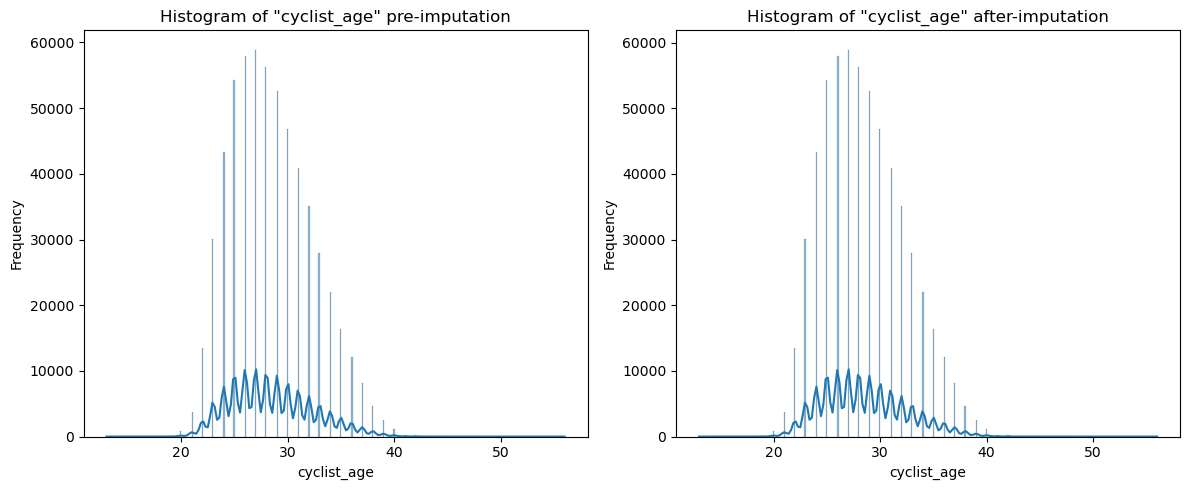

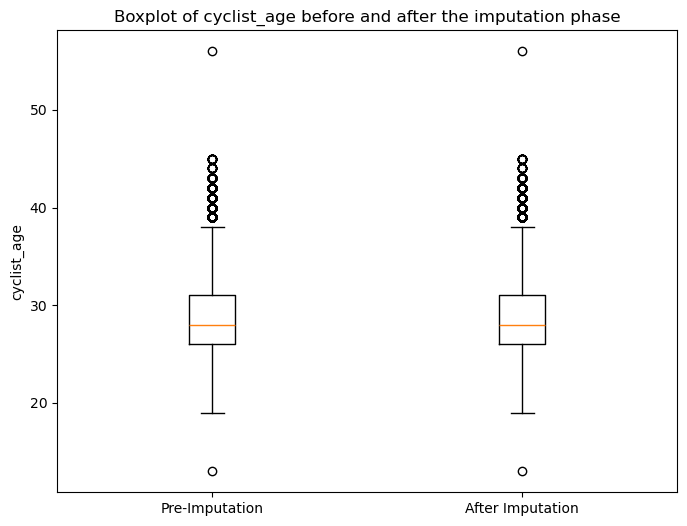

In [128]:
imputationComparison(races_pre_imputation, races, 'cyclist_age')

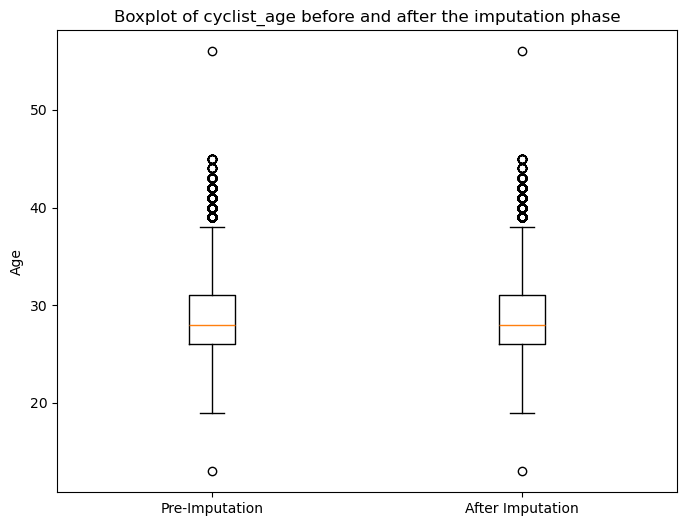

In [129]:
plt.figure(figsize=(8, 6))

#Unique boxplot with multiple datasets representing the initial situation and the imputation strategies
plt.boxplot(
    [races_pre_imputation['cyclist_age'].dropna(), races['cyclist_age']],
    labels=['Pre-Imputation', 'After Imputation']
)
plt.title("Boxplot of cyclist_age before and after the imputation phase")
plt.ylabel("Age")
plt.show()
plt.close()

<Axes: >

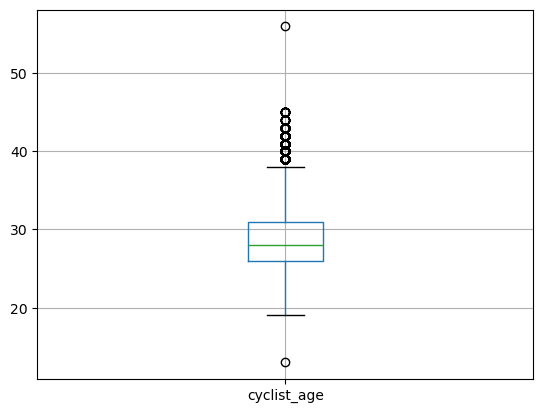

In [130]:
races.boxplot(column='cyclist_age')

## Correzione del delta

Dobbiamo gestire i casi in cui il delta non ha un comportamento crescente. Ciò risolve i casi errati per il delta, sia che siano negativi sia che siano semanticamente non corretti, come posizione inferiore e anche delta inferiore <br>
Possiamo vedere che le righe il cui delta non rispetta un comporamente crescente sono molte

In [131]:
# Crea una nuova colonna per gli errori e inizializzala a False
races['delta_error'] = False

# Funzione per calcolare il massimo tra tutti i precedenti per ogni gruppo
def check_monotonic_errors(group):
    # Ordina il gruppo per posizione
    group = group.sort_values(by='position')
    # Calcola il massimo progressivo tra tutti i valori precedenti (eccetto il valore corrente)
    group['max_previous'] = group['delta'].cummax().shift(1)
    # Verifica se ogni valore è minore del massimo tra i precedenti
    group['delta_error'] = group['delta'] < group['max_previous']
    # Restituisce il gruppo modificato
    return group

# Applica la funzione a ciascun gruppo separato da '_url'
races = races.groupby('_url').apply(check_monotonic_errors).reset_index(drop=True)

races[races['delta_error'] == True]

C:\Users\simon\AppData\Local\Temp\ipykernel_22652\1082095783.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  races = races.groupby('_url').apply(check_monotonic_errors).reset_index(drop=True)


,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,...,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta,climb/length,year,delta_error,max_previous
10893,dauphine/2006/stage-2,Critérium du Dauphiné Libéré,50.0,NaN,203000.0,NaN,NaN,800,NaN,2006-06-06,...,35.0,True,False,False,sweden-2010,323.0,NaN,2006,True,366.0
10901,dauphine/2006/stage-2,Critérium du Dauphiné Libéré,50.0,NaN,203000.0,NaN,NaN,800,NaN,2006-06-06,...,31.0,True,False,False,NaN,323.0,NaN,2006,True,399.0
12610,dauphine/2007/stage-7,Critérium du Dauphiné Libéré,50.0,NaN,129000.0,NaN,NaN,816,NaN,2007-06-17,...,32.0,True,False,False,c-a-1978,37.0,NaN,2007,True,46.0
12852,dauphine/2008/stage-2,Critérium du Dauphiné Libéré,50.0,NaN,194000.0,NaN,NaN,644,NaN,2008-06-09,...,28.0,True,False,False,NaN,4.0,NaN,2008,True,6.0
12853,dauphine/2008/stage-2,Critérium du Dauphiné Libéré,50.0,NaN,194000.0,NaN,NaN,644,NaN,2008-06-09,...,28.0,True,False,False,o.n.c.e.-eroski-2003,4.0,NaN,2008,True,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584457,vuelta-a-espana/2022/stage-2,La Vuelta ciclista a España,80.0,100.0,175100.0,518.0,1.0,968,24.0,2022-08-20,...,21.0,True,False,False,new-zealand-2020,0.0,0.002958,2022,True,142.0
584458,vuelta-a-espana/2022/stage-2,La Vuelta ciclista a España,80.0,100.0,175100.0,518.0,1.0,968,24.0,2022-08-20,...,38.0,True,False,False,slovakia-2008,0.0,0.002958,2022,True,142.0
584459,vuelta-a-espana/2022/stage-2,La Vuelta ciclista a España,80.0,100.0,175100.0,518.0,1.0,968,24.0,2022-08-20,...,31.0,True,False,False,carlos-cycles-1975,0.0,0.002958,2022,True,142.0
584460,vuelta-a-espana/2022/stage-2,La Vuelta ciclista a España,80.0,100.0,175100.0,518.0,1.0,968,24.0,2022-08-20,...,24.0,True,False,False,carlos-cycles-1975,0.0,0.002958,2022,True,142.0


Ovviamente questo controllo individua anche tutte le righe con un delta con valore negativo: non esistono righe senza errore con delta negativo

In [132]:
races[(races['delta_error'] == False) & (races['delta'] < 0)]

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,...,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta,climb/length,year,delta_error,max_previous


Vediamo come varia la distribuzione imputando i valori e determinando il delta come il massimo tra previous e next per ciascun valore

Description of attribute 'delta_log':


C:\Users\simon\AppData\Local\Temp\ipykernel_22652\761862697.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  correct_rows['delta_log'] = np.log(correct_rows['delta'].replace(0, np.nan))


count    467366.000000
mean          5.354865
std           1.652107
min           0.000000
25%           4.276666
50%           5.697093
75%           6.673298
max          11.027556
Name: delta_log, dtype: float64


Unique values:
[       nan 3.09104245 3.49650756 ... 7.784057   7.80547463 7.81318727]

Null values: 119260 over 586626 records - (20.33%)

Top 5 common value:
delta_log
0.693147    3624
1.609438    3295
1.098612    3163
1.791759    2971
1.386294    2858
Name: count, dtype: int64


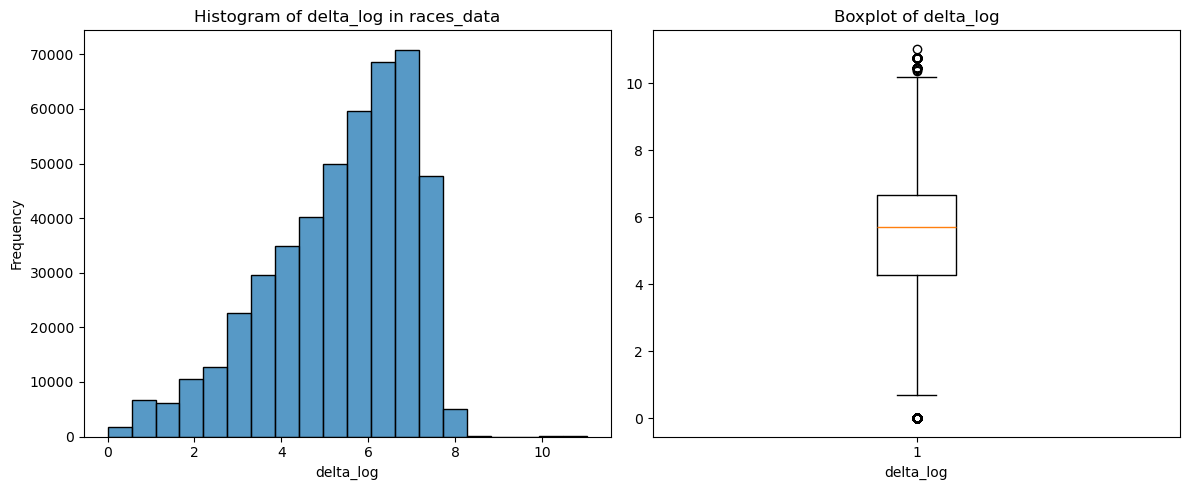

Outliers in delta_log: [0.0, 10.408496290980555, 10.456165040324679, 10.355836246543143, 10.744623610809523, 10.449381047562612, 11.027556389563637]
Description of attribute 'delta':


count    586626.000000
mean        419.822066
std         841.405594
min           0.000000
25%          11.000000
50%         158.000000
75%         627.000000
max       61547.000000
Name: delta, dtype: float64


Unique values:
[   0.   22.   33. ... 2402. 2454. 2473.]

Null values: 0 over 586626 records - (0.00%)

Top 5 common value:
delta
0.0    119260
2.0      3624
5.0      3295
3.0      3163
6.0      2971
Name: count, dtype: int64


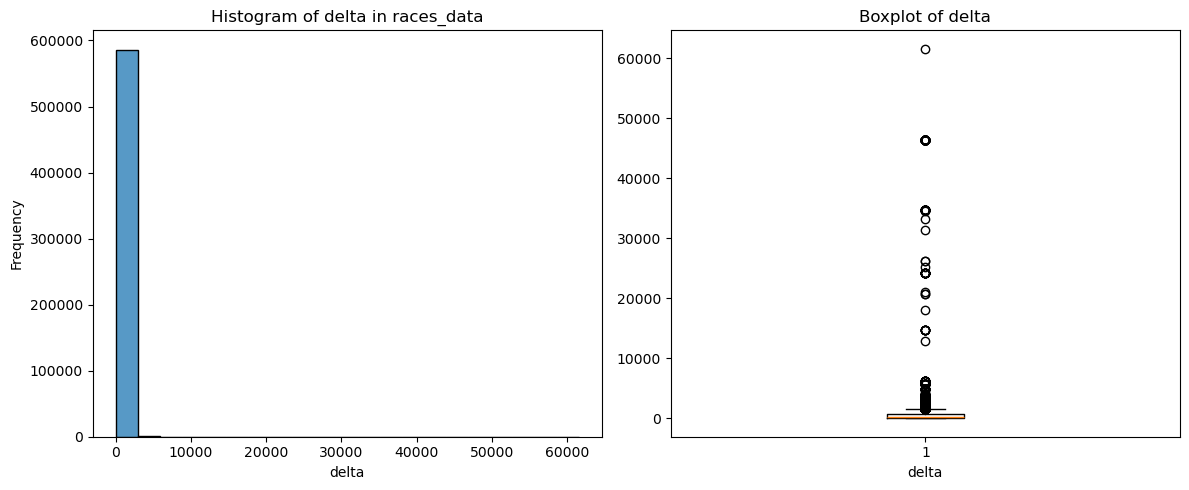

Outliers in delta: [2048.0, 2049.0, 2050.0, 2051.0, 2052.0, 2053.0, 2054.0, 2055.0, 2056.0, 2057.0, 2058.0, 2059.0, 2060.0, 2061.0, 2062.0, 2063.0, 2064.0, 2065.0, 2066.0, 2067.0, 2068.0, 2069.0, 2070.0, 2071.0, 2072.0, 2073.0, 2074.0, 2075.0, 2076.0, 2077.0, 2078.0, 2079.0, 2080.0, 2081.0, 2082.0, 2083.0, 2084.0, 2085.0, 2086.0, 2087.0, 2088.0, 2089.0, 2090.0, 2091.0, 2092.0, 2093.0, 2094.0, 2095.0, 2096.0, 2097.0, 2098.0, 2099.0, 2100.0, 2101.0, 2102.0, 2103.0, 2105.0, 2106.0, 2107.0, 2108.0, 2109.0, 2110.0, 2111.0, 2112.0, 2113.0, 2114.0, 2115.0, 2116.0, 2117.0, 2118.0, 2119.0, 2120.0, 2121.0, 2122.0, 2123.0, 2124.0, 2125.0, 2126.0, 2127.0, 2128.0, 2129.0, 2130.0, 2131.0, 2132.0, 2133.0, 2134.0, 2135.0, 2136.0, 2137.0, 2138.0, 2139.0, 2140.0, 2141.0, 2142.0, 2143.0, 2144.0, 2145.0, 2146.0, 2147.0, 2148.0, 2149.0, 2150.0, 2151.0, 2152.0, 2153.0, 2154.0, 2155.0, 61547.0, 2157.0, 2158.0, 2159.0, 2160.0, 2156.0, 2162.0, 2163.0, 2164.0, 2165.0, 2166.0, 2167.0, 2168.0, 2169.0, 2170.0, 217

In [133]:
import numpy as np

correct_rows = races[(races['delta_error'] == False)]
correct_rows['delta_log'] = np.log(correct_rows['delta'].replace(0, np.nan))
stats_and_distribution(correct_rows, 'delta_log', attr_type='numerical')
stats_and_distribution(correct_rows, 'delta', attr_type='numerical')

In [134]:
# Funzione per calcolare il massimo tra tutti i precedenti per ogni gruppo
def adjust_monotonic_errors(group):
    # Ordina il gruppo per posizione
    group = group.sort_values(by='position')
    mask = group['delta_error'] == True
    # Calcola il massimo progressivo tra tutti i valori precedenti e il successivo
    correct_delta = group['delta'].cummax().shift(-1)
    # Riempie eventuali NaN nell'ultimo valore con l'ultimo valore valido
    correct_delta = correct_delta.ffill() 
    # Verifica se ogni valore è minore del massimo tra i precedenti
    group.loc[mask, 'delta'] = correct_delta[mask]
    # Restituisce il gruppo modificato
    return group

# Applica la funzione a ciascun gruppo separato da '_url'
races = races.groupby('_url').apply(adjust_monotonic_errors).reset_index(drop=True)

C:\Users\simon\AppData\Local\Temp\ipykernel_22652\3605015566.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  races = races.groupby('_url').apply(adjust_monotonic_errors).reset_index(drop=True)


Controlliamo se abbiamo corretto errori sul valore delta

In [135]:
# Verifica se la colonna 'delta' è monotona crescente per ciascun gruppo
monotonic_status = races.groupby('_url')['delta'].apply(lambda x: x.is_monotonic_increasing)

# Mostra il risultato
print("Tutti i gruppi sono monotoni crescenti:",  monotonic_status.all())

Tutti i gruppi sono monotoni crescenti: True


Controlliamo anche con la funzione prima usata e vediamo che nessun record verrà ritornato

In [136]:
# Applica la funzione a ciascun gruppo separato da '_url'
races = races.groupby('_url').apply(check_monotonic_errors).reset_index(drop=True)

races[races['delta_error'] == True]

C:\Users\simon\AppData\Local\Temp\ipykernel_22652\1280869726.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  races = races.groupby('_url').apply(check_monotonic_errors).reset_index(drop=True)


,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,...,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta,climb/length,year,delta_error,max_previous


Analizziamo la distribuzione dopo correzione: gli outlier rimangono gli stessi e i quantili sono rispettati. In generale la distribuzione non è intaccata dalla trasformazione e siamo riusciti a risolvere il problema semantico!

Description of attribute 'delta':


count    589865.000000
mean        430.941419
std        1015.035583
min           0.000000
25%          11.000000
50%         158.000000
75%         626.000000
max       61547.000000
Name: delta, dtype: float64


Unique values:
[   0.   22.   33. ... 2402. 2454. 2473.]

Null values: 0 over 589865 records - (0.00%)

Top 5 common value:
delta
0.0    119269
2.0      3625
5.0      3295
6.0      3183
3.0      3163
Name: count, dtype: int64


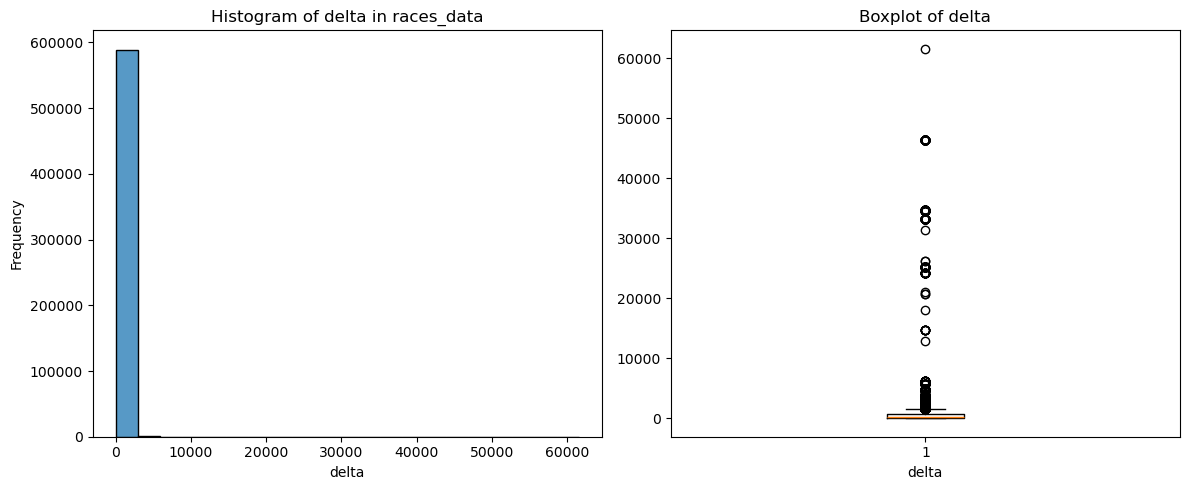

Outliers in delta: [2048.0, 2049.0, 2050.0, 2051.0, 2052.0, 2053.0, 2054.0, 2055.0, 2056.0, 2057.0, 2058.0, 2059.0, 2060.0, 2061.0, 2062.0, 2063.0, 2064.0, 2065.0, 2066.0, 2067.0, 2068.0, 2069.0, 2070.0, 2071.0, 2072.0, 2073.0, 2074.0, 2075.0, 2076.0, 2077.0, 2078.0, 2079.0, 2080.0, 2081.0, 2082.0, 2083.0, 2084.0, 2085.0, 2086.0, 2087.0, 2088.0, 2089.0, 2090.0, 2091.0, 2092.0, 2093.0, 2094.0, 2095.0, 2096.0, 2097.0, 2098.0, 2099.0, 2100.0, 2101.0, 2102.0, 2103.0, 2105.0, 2106.0, 2107.0, 2108.0, 2109.0, 2110.0, 2111.0, 2112.0, 2113.0, 2114.0, 2115.0, 2116.0, 2117.0, 2118.0, 2119.0, 2120.0, 2121.0, 2122.0, 2123.0, 2124.0, 2125.0, 2126.0, 2127.0, 2128.0, 2129.0, 2130.0, 2131.0, 2132.0, 2133.0, 2134.0, 2135.0, 2136.0, 2137.0, 2138.0, 2139.0, 2140.0, 2141.0, 2142.0, 2143.0, 2144.0, 2145.0, 2146.0, 2147.0, 2148.0, 2149.0, 2150.0, 2151.0, 2152.0, 2153.0, 2154.0, 2155.0, 61547.0, 2157.0, 2158.0, 2159.0, 2160.0, 2156.0, 2162.0, 2163.0, 2164.0, 2165.0, 2166.0, 2167.0, 2168.0, 2169.0, 2170.0, 217

count    470596.000000
mean          5.355173
std           1.655009
min           0.000000
25%           4.276666
50%           5.693732
75%           6.673298
max          11.027556
Name: delta_log, dtype: float64


Unique values:
[       nan 3.09104245 3.49650756 ... 7.784057   7.80547463 7.81318727]

Null values: 119269 over 589865 records - (20.22%)

Top 5 common value:
delta_log
0.693147    3625
1.609438    3295
1.791759    3183
1.098612    3163
1.386294    2858
Name: count, dtype: int64


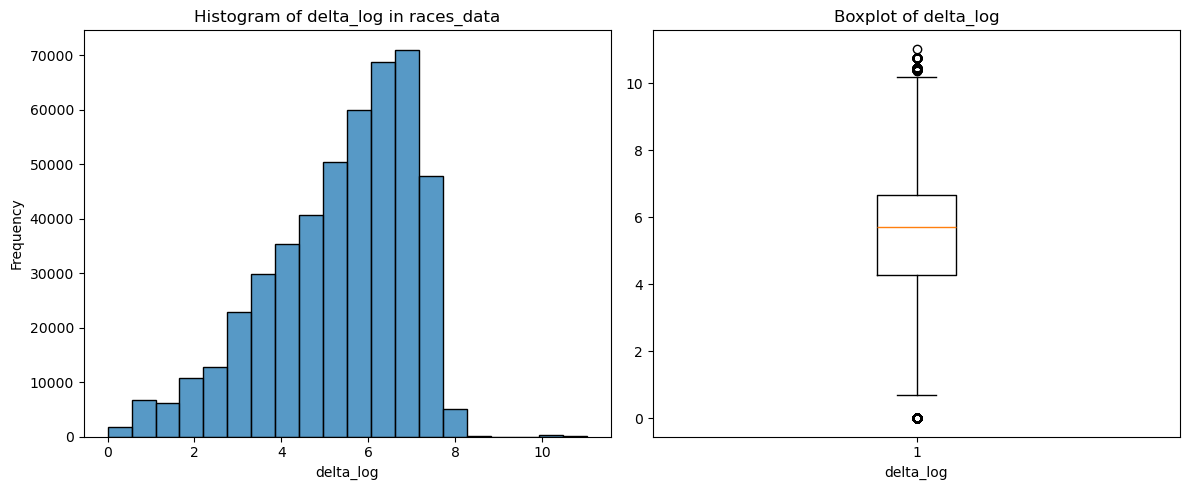

Outliers in delta_log: [0.0, 10.408496290980555, 10.456165040324679, 10.355836246543143, 10.744623610809523, 10.449381047562612, 11.027556389563637]


In [137]:
races['delta_log'] = np.log(races['delta'].replace(0, np.nan))
stats_and_distribution(races, 'delta', attr_type='numerical')
stats_and_distribution(races, 'delta_log', attr_type='numerical')

In [138]:
#races = races.drop(columns=['delta_error', 'max_previous', 'delta_log'])
races = races.drop(columns=['delta_error', 'max_previous'])

## Climb total


In [139]:
import pandas as pd
#races_data = pd.read_csv('../dataset/preprocessedRacesData.csv', sep=",")
#races_data_pre_imputation=races_data.copy()
#races = pd.read_csv('../dataset/preprocessedRaces.csv', sep=",")

In [140]:
races.columns

Index(['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'date',
       'position', 'cyclist', 'cyclist_age', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'cyclist_team', 'delta', 'climb/length', 'year',
       'delta_log'],
      dtype='object')

In [141]:
races['mean delta']=races.groupby('_url')['delta'].transform('mean')
races['std delta']=races.groupby('_url')['delta'].transform('std')
races_pre_imputation=races.copy()

In [142]:
races.columns

Index(['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'date',
       'position', 'cyclist', 'cyclist_age', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'cyclist_team', 'delta', 'climb/length', 'year',
       'delta_log', 'mean delta', 'std delta'],
      dtype='object')

In [143]:
races

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,...,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta,climb/length,year,delta_log,mean delta,std delta
0,amstel-gold-race/1970/result,Amstel Gold Race,225.0,NaN,240000.0,NaN,NaN,372,NaN,1970-04-25,...,False,False,False,norway-1987,0.0,NaN,1970,NaN,76.87500,96.759863
1,amstel-gold-race/1970/result,Amstel Gold Race,225.0,NaN,240000.0,NaN,NaN,372,NaN,1970-04-25,...,False,False,False,norway-1987,0.0,NaN,1970,NaN,76.87500,96.759863
2,amstel-gold-race/1970/result,Amstel Gold Race,225.0,NaN,240000.0,NaN,NaN,372,NaN,1970-04-25,...,False,False,False,spain-1991,22.0,NaN,1970,3.091042,76.87500,96.759863
3,amstel-gold-race/1970/result,Amstel Gold Race,225.0,NaN,240000.0,NaN,NaN,372,NaN,1970-04-25,...,False,False,False,spain-1991,33.0,NaN,1970,3.496508,76.87500,96.759863
4,amstel-gold-race/1970/result,Amstel Gold Race,225.0,NaN,240000.0,NaN,NaN,372,NaN,1970-04-25,...,False,False,False,NaN,33.0,NaN,1970,3.496508,76.87500,96.759863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589860,world-championship/2022/result,World Championships ME - Road Race,350.0,600.0,266900.0,4167.0,2.0,1052,NaN,2022-09-25,...,False,False,False,kazakhstan-2022,688.0,0.015613,2022,6.533789,321.61165,218.624453
589861,world-championship/2022/result,World Championships ME - Road Race,350.0,600.0,266900.0,4167.0,2.0,1052,NaN,2022-09-25,...,False,False,False,denmark-2016,700.0,0.015613,2022,6.551080,321.61165,218.624453
589862,world-championship/2022/result,World Championships ME - Road Race,350.0,600.0,266900.0,4167.0,2.0,1052,NaN,2022-09-25,...,False,False,False,denmark-2016,868.0,0.015613,2022,6.766192,321.61165,218.624453
589863,world-championship/2022/result,World Championships ME - Road Race,350.0,600.0,266900.0,4167.0,2.0,1052,NaN,2022-09-25,...,False,False,False,liberty-seguros-wurth-team-2005,905.0,0.015613,2022,6.807935,321.61165,218.624453


In [144]:
## Anzichè fare questa cosa della drop duplicates dovrei fare una merge

In [145]:
temp=races[['_url','mean delta', 'std delta']].drop_duplicates()
temp

,_url,mean delta,std delta
0,amstel-gold-race/1970/result,76.875000,96.759863
40,amstel-gold-race/1971/result,121.234043,60.071773
87,amstel-gold-race/1972/result,122.655172,228.065197
116,amstel-gold-race/1973/result,505.428571,191.357805
144,amstel-gold-race/1974/result,337.400000,308.952691
...,...,...,...
589484,world-championship/2018/result,395.618421,354.014273
589560,world-championship/2019/result,268.673913,282.965570
589606,world-championship/2020/result,671.500000,544.798940
589694,world-championship/2021/result,374.529412,238.715560


In [146]:
races_data=pd.merge(races_data, temp, how='inner', left_on='_url', right_on='_url')
races_data=races_data.reset_index()
races_data

,index,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length,mean delta,std delta
0,0,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,True,False,False,0.006796,26.075472,6.847590
1,1,vuelta-a-espana/2016/stage-14,Vuelta a España,80.0,100.0,196000.0,5575.0,5.0,821,NaN,True,False,False,0.028444,1508.787879,873.835670
2,2,tour-de-france/2019/stage-21,Tour de France,100.0,120.0,128000.0,781.0,1.0,1699,NaN,True,False,False,0.006102,39.612903,44.079531
3,3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50.0,NaN,8100.0,NaN,NaN,804,NaN,True,False,False,NaN,57.436975,27.154498
4,4,tour-de-france/2022/stage-9,Tour de France,100.0,120.0,192900.0,3743.0,3.0,1551,24.0,True,False,False,0.019404,1140.963415,675.354230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5276,5276,giro-d-italia/2017/stage-3,Giro d'Italia,80.0,100.0,148000.0,1441.0,1.0,881,NaN,True,False,False,0.009736,134.835897,120.702086
5277,5277,paris-roubaix/2000/result,Paris - Roubaix,275.0,NaN,273000.0,NaN,1.0,808,NaN,False,False,False,NaN,389.666667,327.665558
5278,5278,paris-nice/1976/stage-2,Paris - Nice,50.0,NaN,185000.0,NaN,NaN,779,NaN,True,False,False,NaN,0.000000,0.000000
5279,5279,volta-a-catalunya/2016/stage-7,Volta Ciclista a Catalunya,50.0,50.0,136400.0,1880.0,2.0,1045,NaN,True,False,False,0.013783,221.936508,176.293335


In [147]:
races_data.drop('index', axis=1, inplace=True)

In [148]:
races_data.isna().sum()

_url                      0
name                      0
points                    0
uci_points             3682
length                    0
climb_total            2214
profile                2408
startlist_quality         0
average_temperature    5076
is_tarmac                 0
is_cobbled                0
is_gravel                 0
climb/length           2214
mean delta                0
std delta                 6
dtype: int64

In [149]:
races_data.shape[0]

5281

There are 2214 missing '_climb total_' over 5281 race events, almost the 42%.

In [150]:
no_climb_total_urls=races_data[races_data['climb_total'].isna()]['_url'].tolist()

In [152]:
races_data_pre_imputation=races_data.copy()

### Uso solo le features di races_data cioè climb_total, length, startlist_quality, points

In [153]:
from sklearn.impute import KNNImputer
#Missing value mitigation using the value of the "near" (in the KNN sense) instances

#No 'profile' because it is a categorical
columns_for_imputation = ['climb_total', 'length', 'startlist_quality', 'points']
imputer = KNNImputer(n_neighbors=4,weights="distance")
imputed_data = imputer.fit_transform(races_data[columns_for_imputation])

In [154]:
df_imputed=pd.DataFrame(imputed_data, columns=columns_for_imputation)
races_data['climb_total']=df_imputed['climb_total']

In [155]:
races_data['climb_total'].isna().any()

False

In [156]:
races_data_pre_imputation.columns

Index(['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'is_tarmac',
       'is_cobbled', 'is_gravel', 'climb/length', 'mean delta', 'std delta'],
      dtype='object')

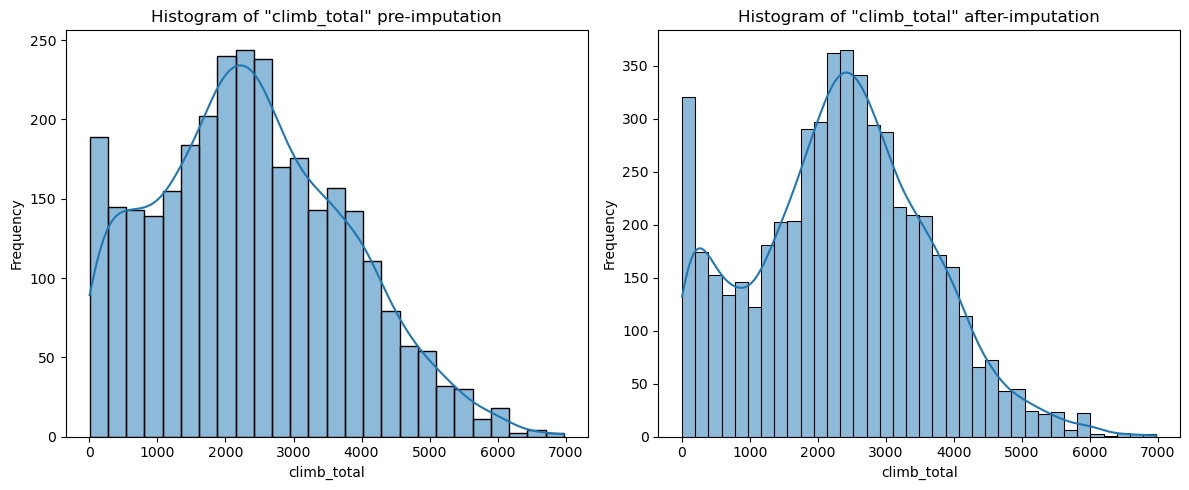

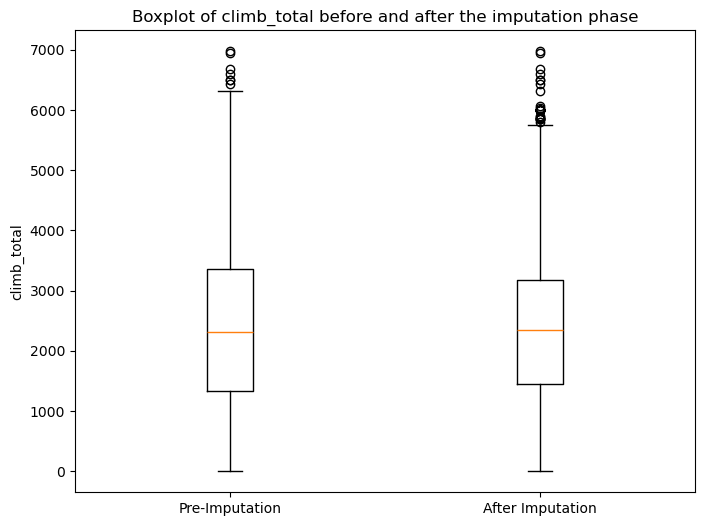

In [157]:
imputationComparison(races_data_pre_imputation, races_data, 'climb_total')

In [159]:
columns_for_imputation = ['climb_total', 'length', 'startlist_quality', 'points']
column_to_be_imputed='climb_total'

In [160]:
def try_knn_imputation(k, dataframe_preImp, dataframe_actual, columns_for_imputation, column_to_be_imputed):
    print(f"KNN Test with k={k}")
    imputer = KNNImputer(n_neighbors=k,weights="distance")
    imputed_data = imputer.fit_transform(dataframe_actual[columns_for_imputation])

    df_imputed=pd.DataFrame(imputed_data, columns=columns_for_imputation)
    dataframe_actual[[column_to_be_imputed]]=df_imputed[[column_to_be_imputed]]

    imputationComparison(dataframe_preImp, dataframe_actual, column_to_be_imputed)

KNN Test with k=1


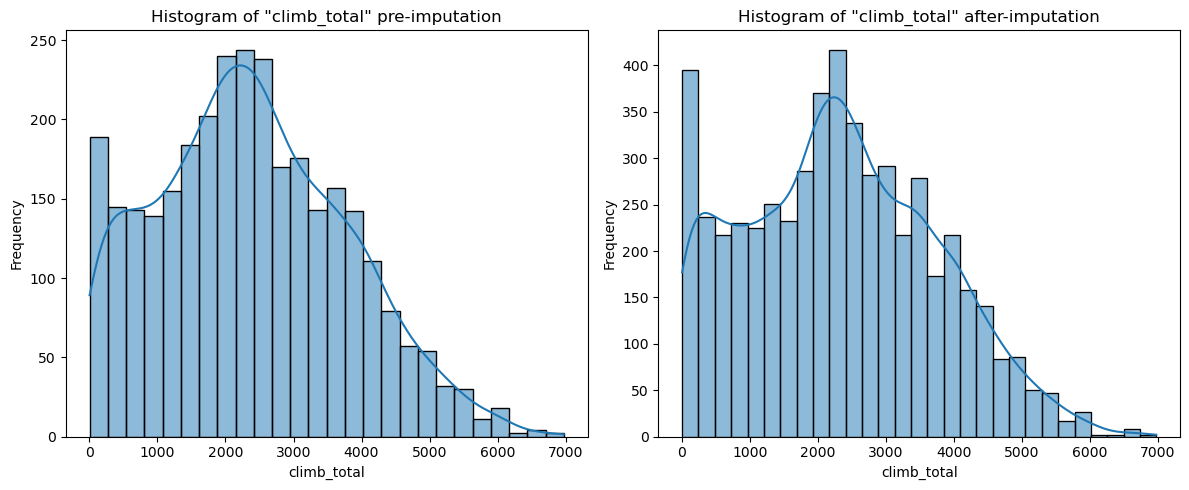

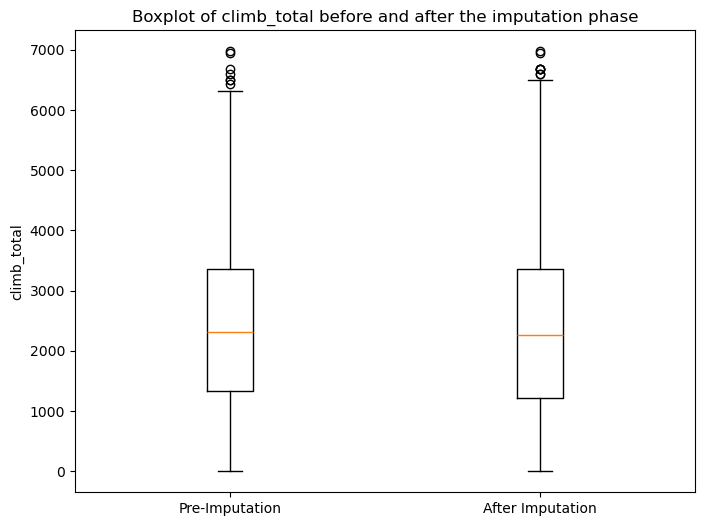

In [161]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(1, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=2


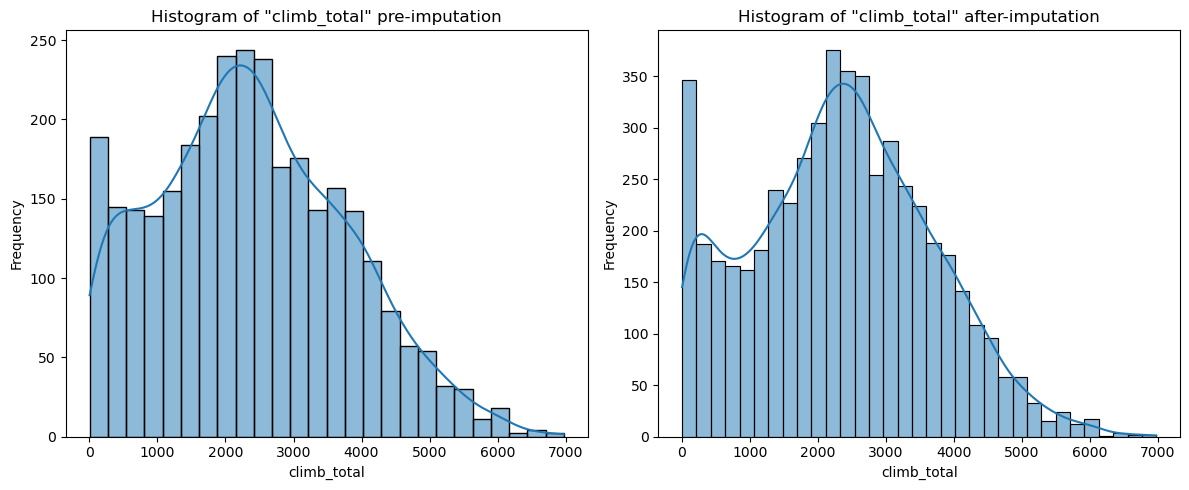

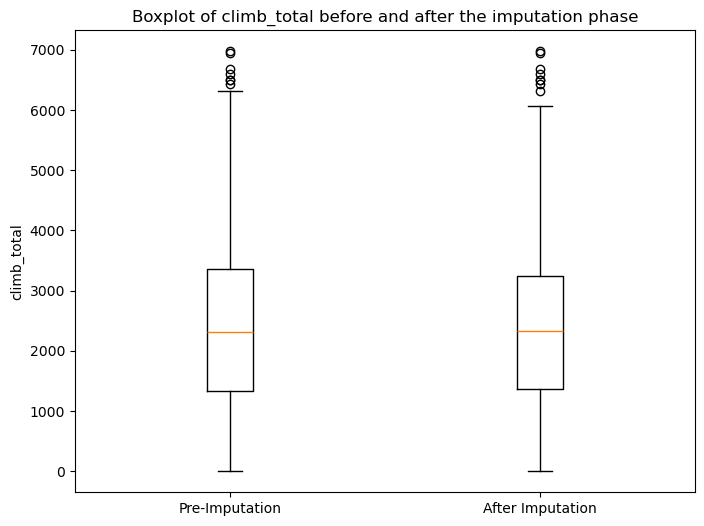

In [162]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(2, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=3


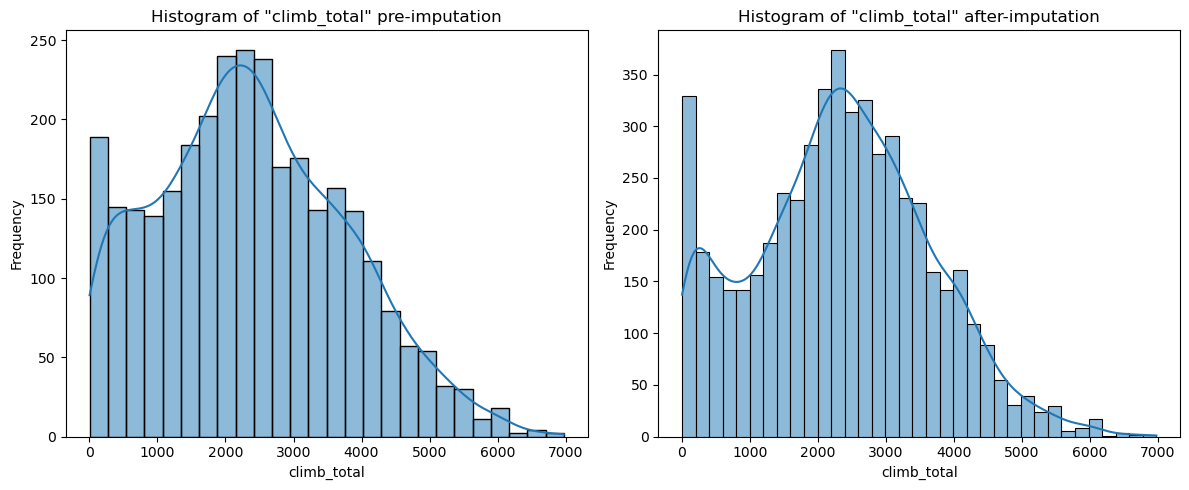

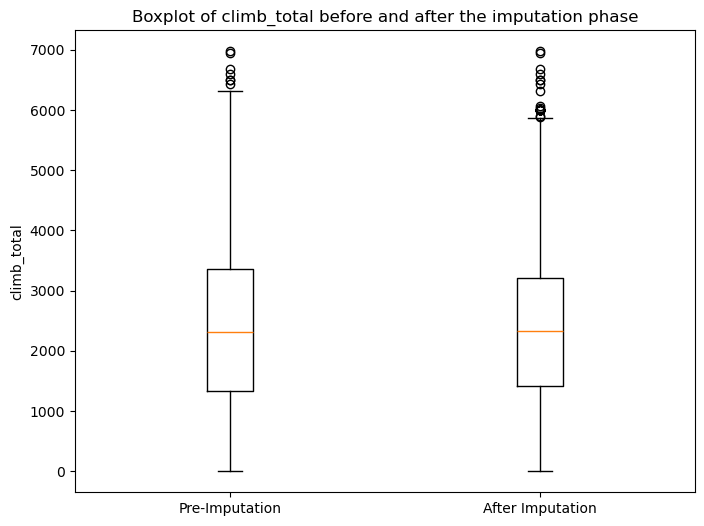

In [163]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(3, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=4


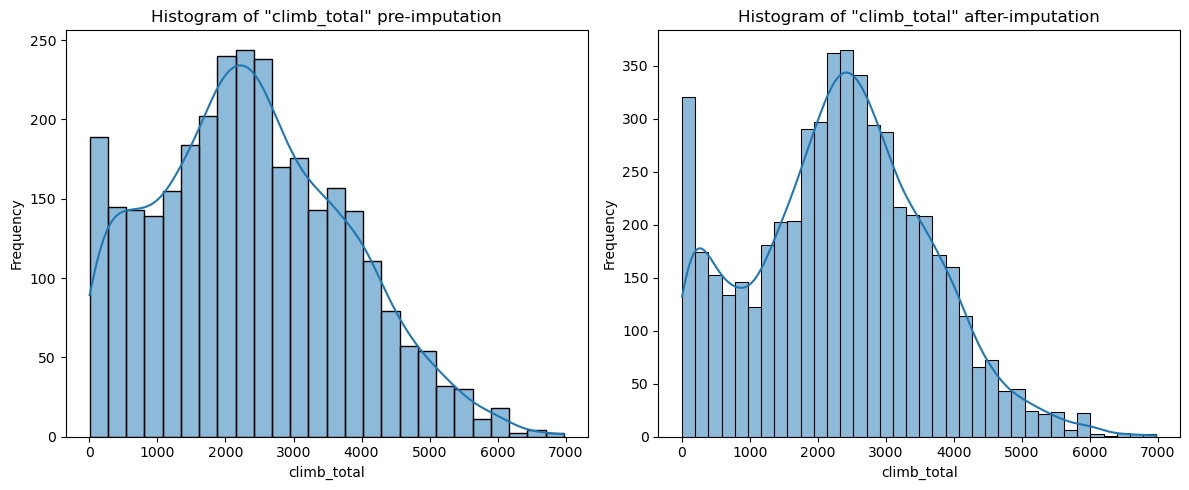

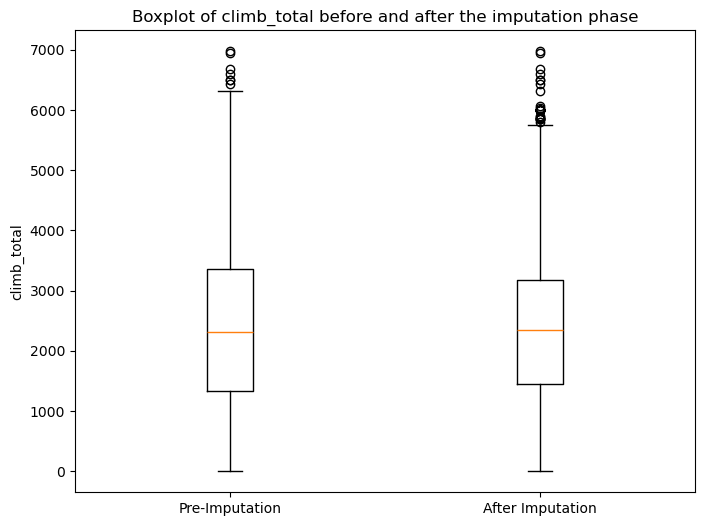

In [164]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(4, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=5


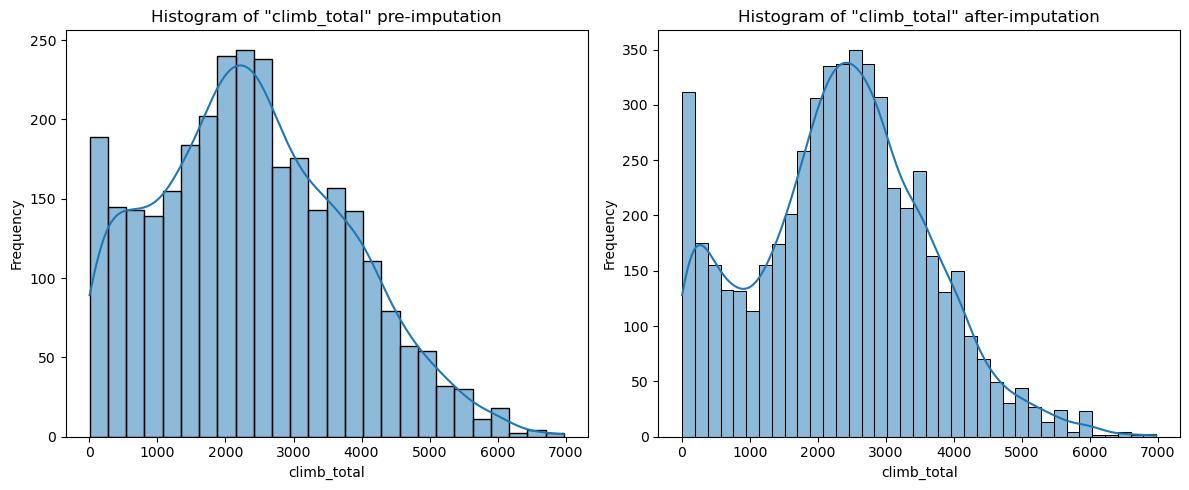

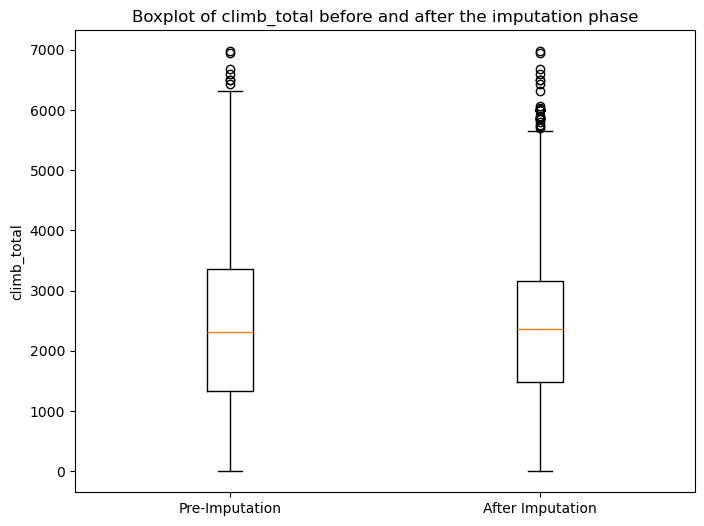

In [165]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(5, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=6


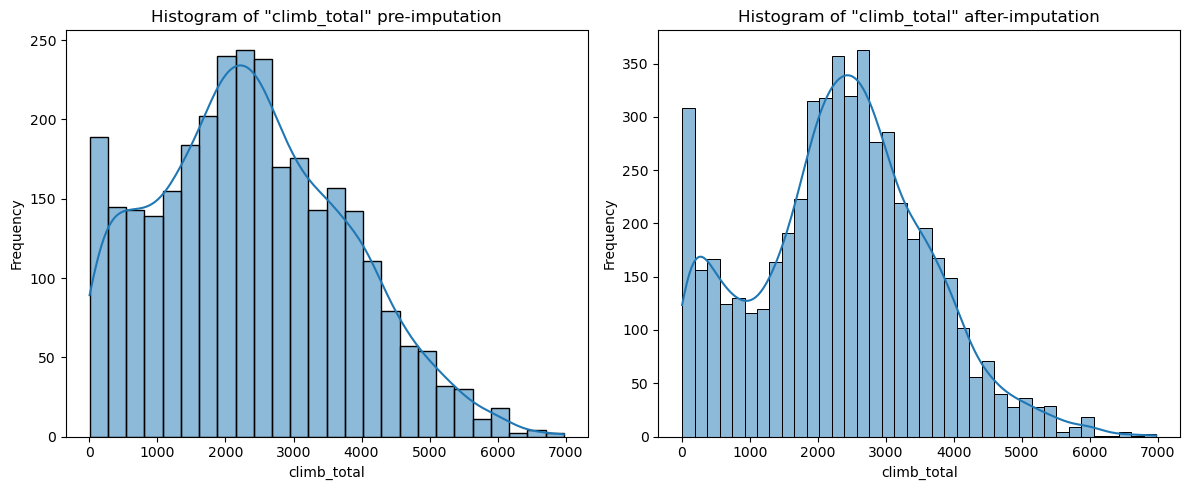

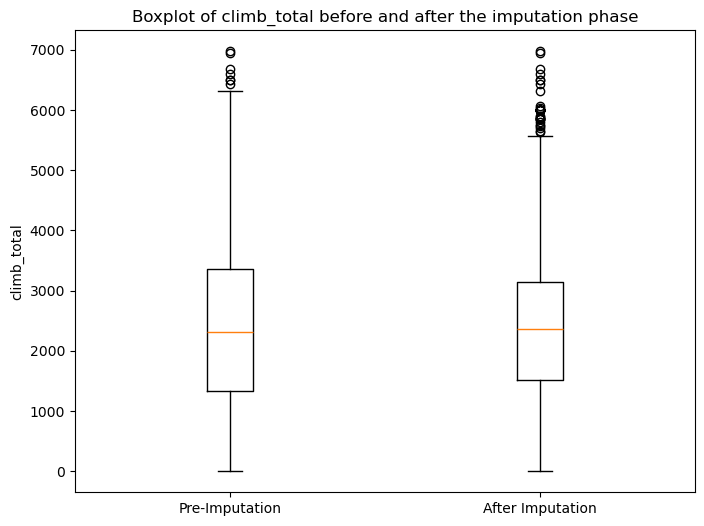

In [166]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(6, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=7


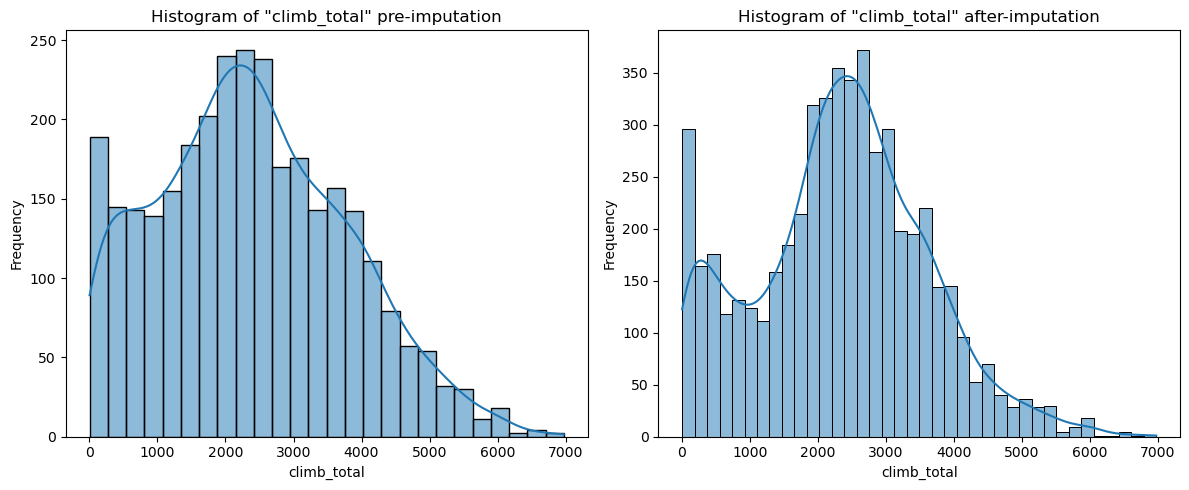

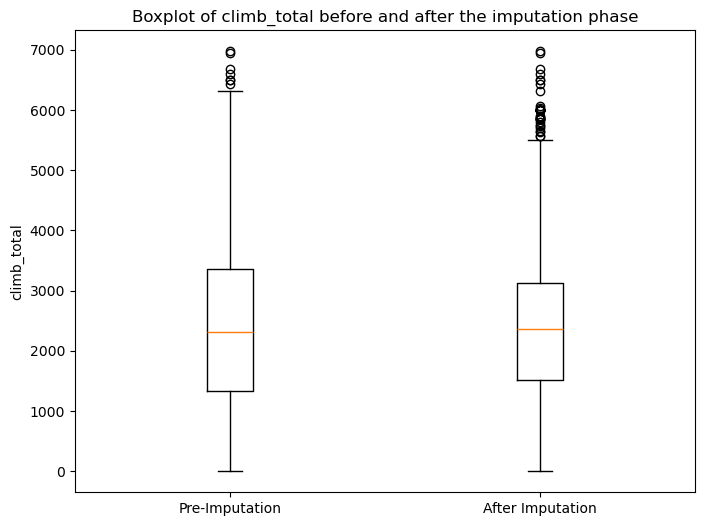

In [167]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(7, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=8


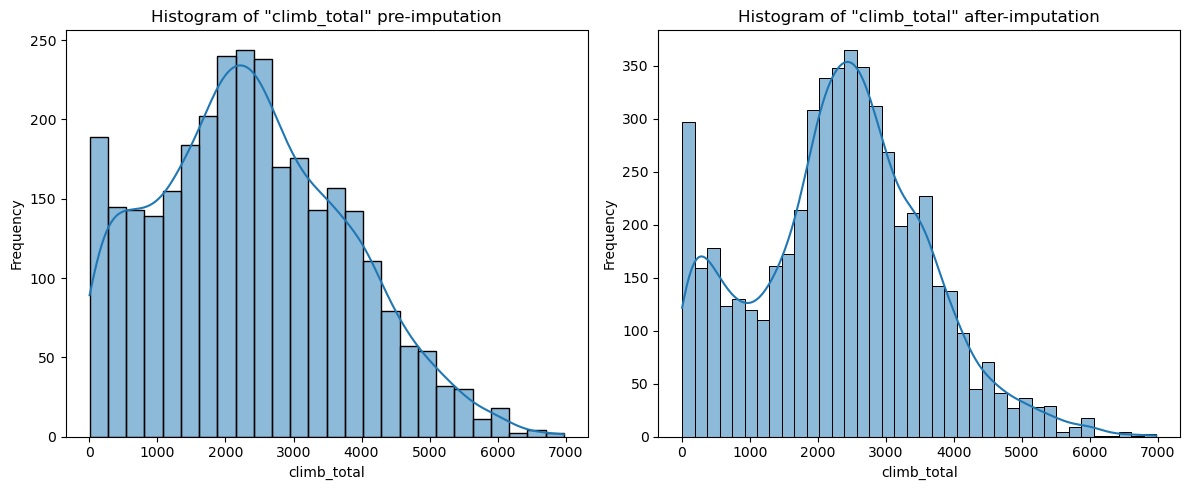

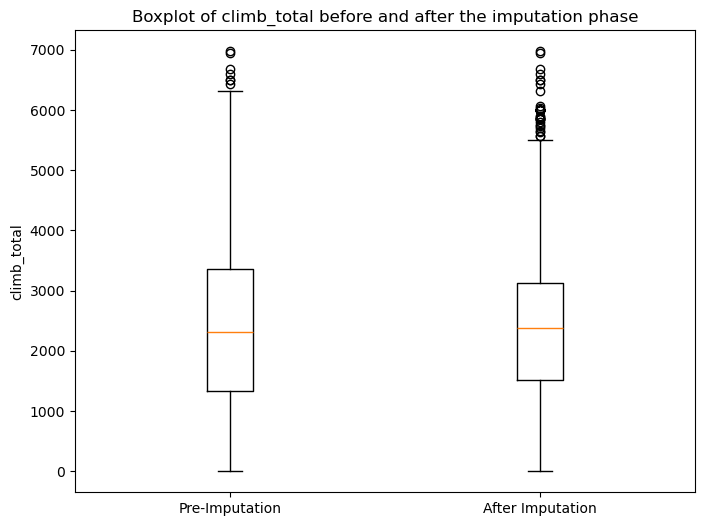

In [168]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(8, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=9


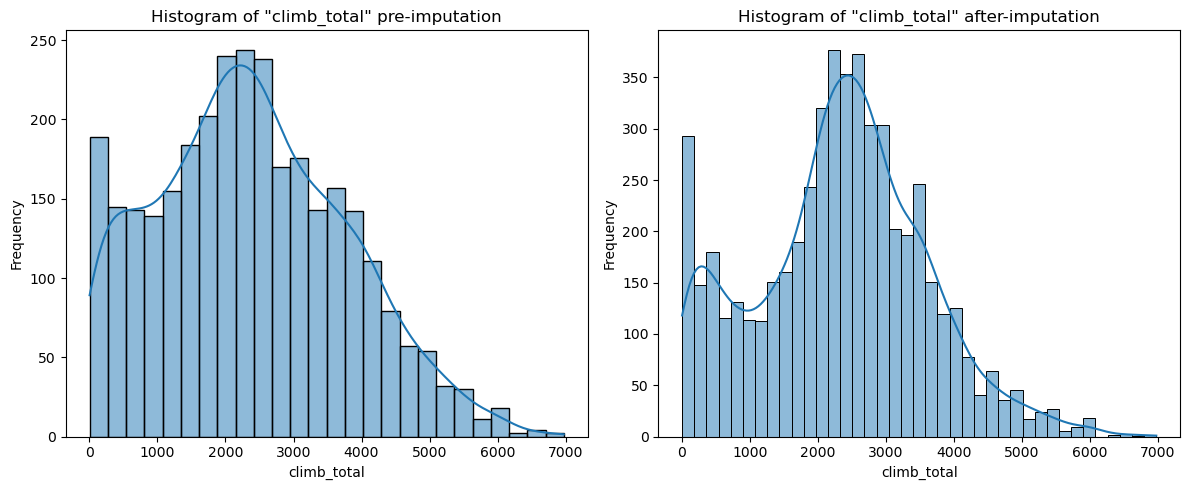

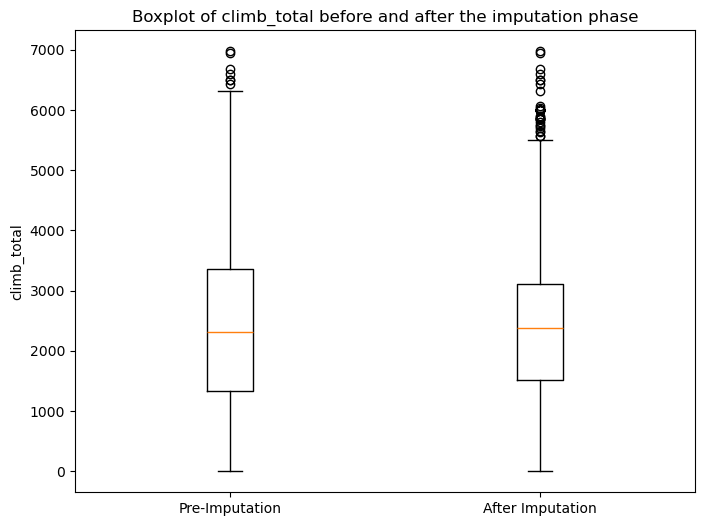

In [169]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(9, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=10


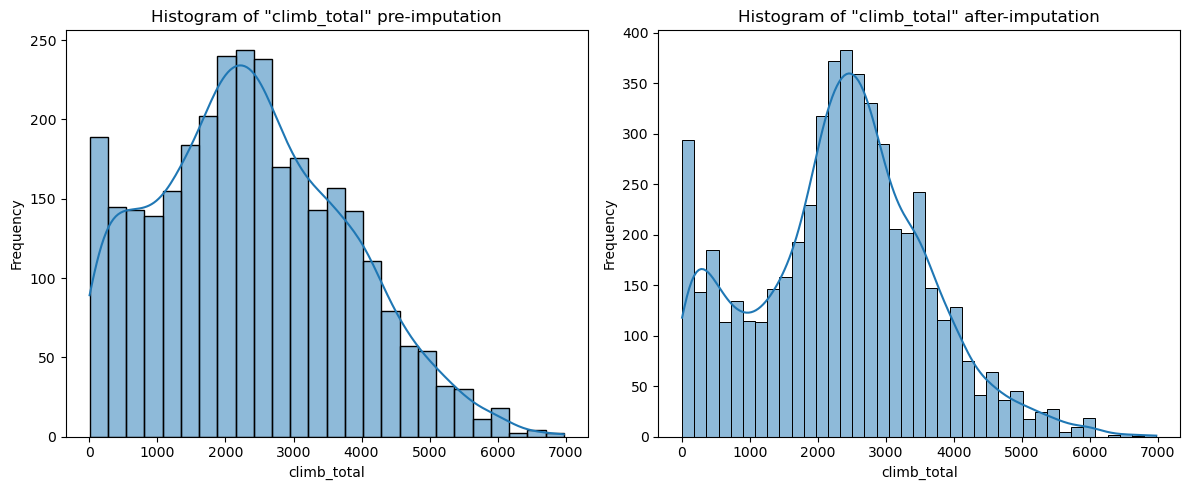

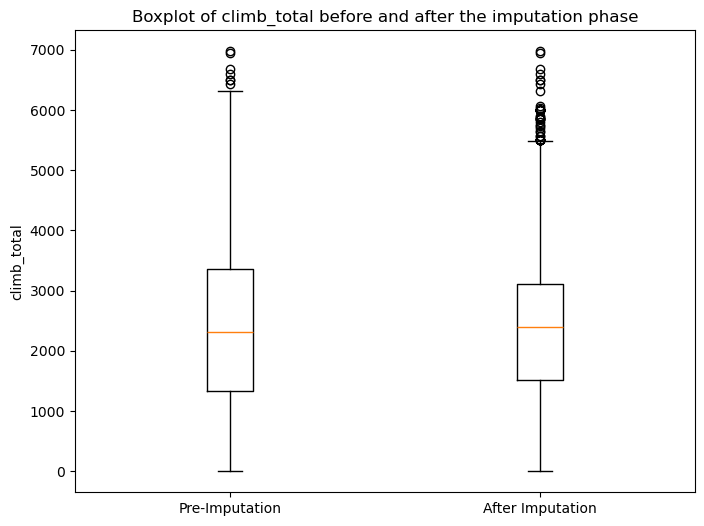

In [170]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(10, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=12


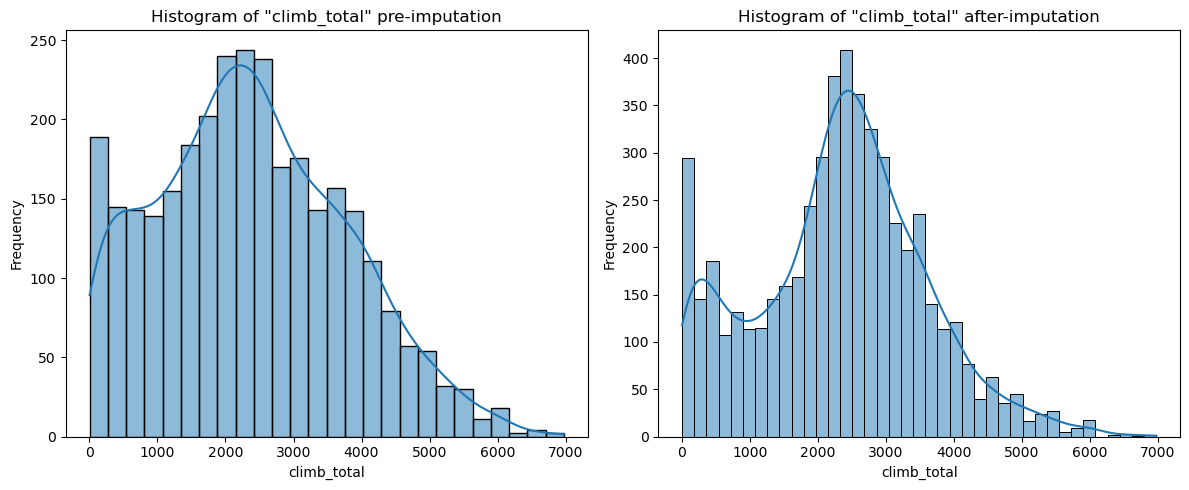

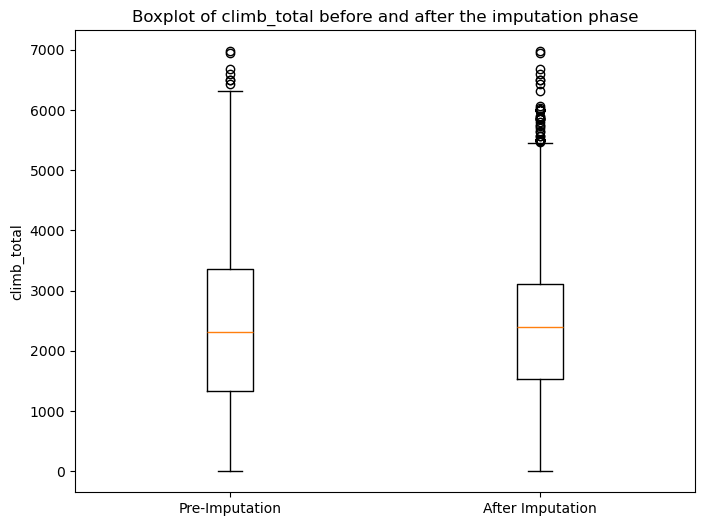

In [171]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(12, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

As we can observe from the changes in the distribution, the best choices of k are probably 2, 3, 4, 5.

KNN Test with k=5


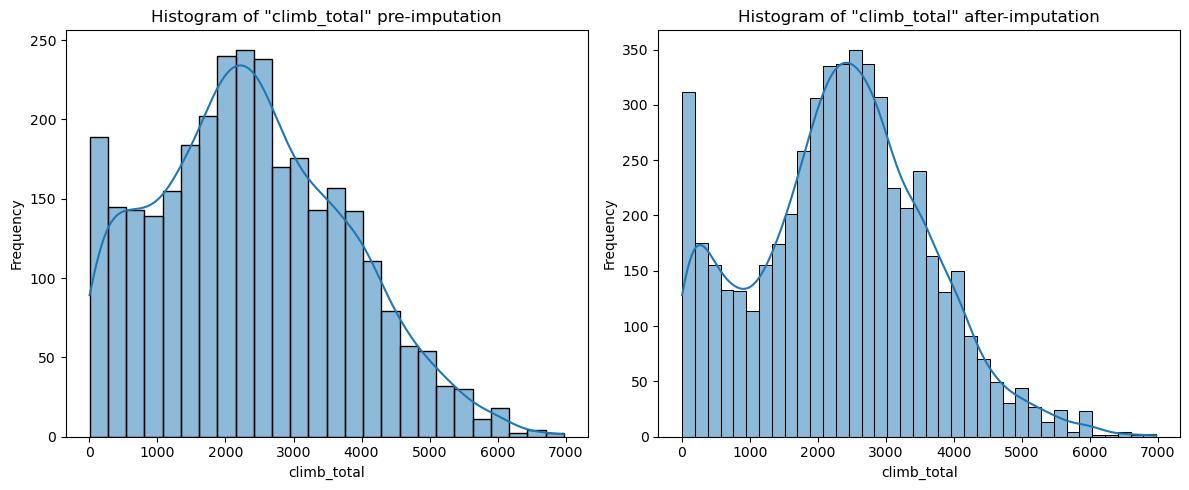

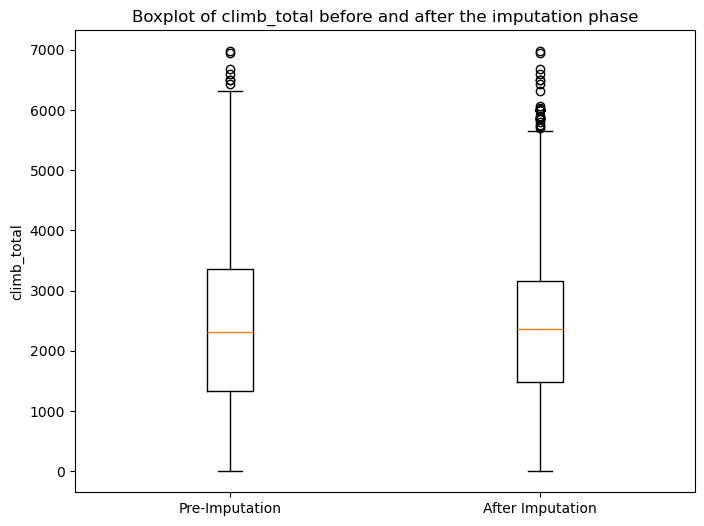

In [176]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(5, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

In [185]:
races_data_pre_imputation['climb_total'].describe()

count    3067.000000
mean     2375.650473
std      1394.390513
min         2.000000
25%      1333.000000
50%      2307.000000
75%      3358.000000
max      6974.000000
Name: climb_total, dtype: float64

In [186]:
races_data['climb_total'].describe()

count    5281.000000
mean     2331.373124
std      1277.250002
min         2.000000
25%      1484.000000
50%      2365.000000
75%      3161.350692
max      6974.000000
Name: climb_total, dtype: float64

In [177]:
len(no_climb_total_urls)

2214

In [178]:
races_data.columns

Index(['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'is_tarmac',
       'is_cobbled', 'is_gravel', 'climb/length', 'mean delta', 'std delta'],
      dtype='object')

In [ ]:
#update after imputation
races_data['climb/length'] = races_data['climb_total'] / races_data['length']

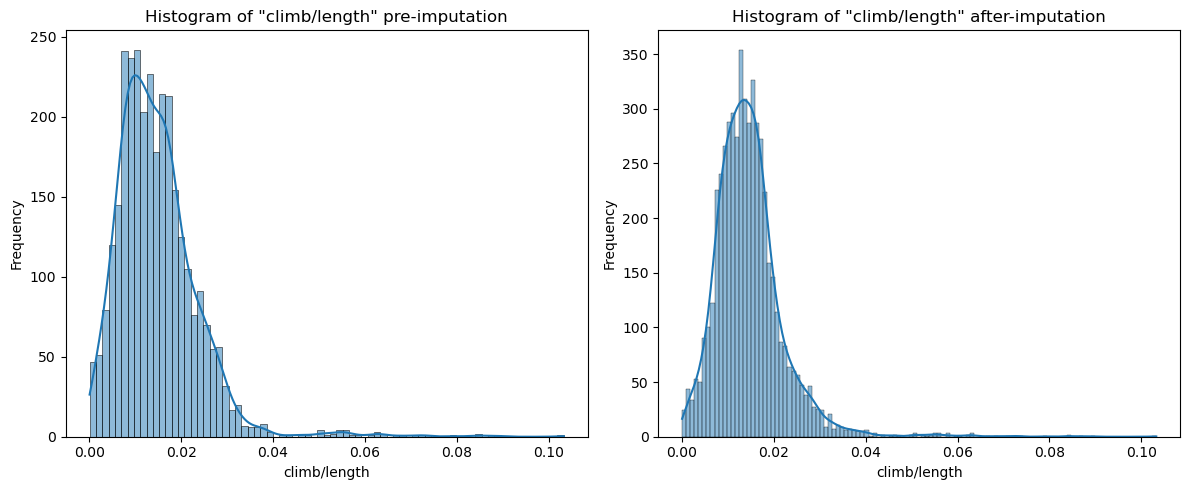

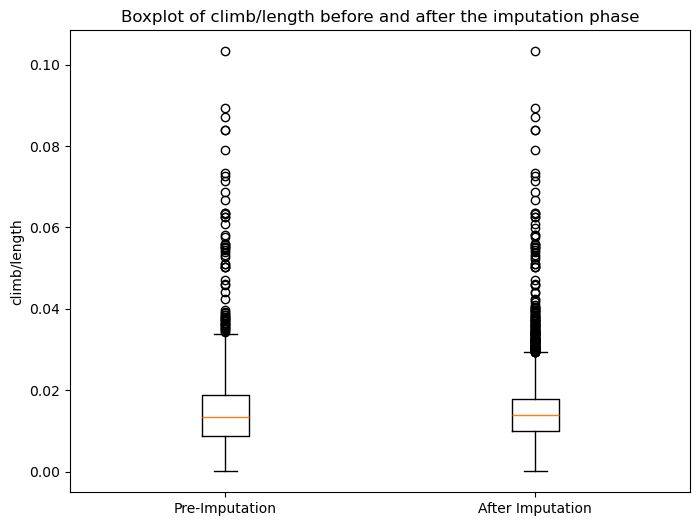

In [182]:
imputationComparison(races_data_pre_imputation, races_data, 'climb/length')

In [183]:
races_data_pre_imputation['climb/length'].describe()

count    3067.000000
mean        0.014813
std         0.009059
min         0.000069
25%         0.008803
50%         0.013438
75%         0.018845
max         0.103261
Name: climb/length, dtype: float64

In [184]:
races_data['climb/length'].describe()

count    5281.000000
mean        0.014733
std         0.007732
min         0.000069
25%         0.010033
50%         0.013795
75%         0.017778
max         0.103261
Name: climb/length, dtype: float64

### Aggiungo anche nuove features di races_data relative al delta dei piazzamenti per ciascuna gara

In [187]:
races_data=races_data_pre_imputation.copy()

In [189]:
races_data

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length,mean delta,std delta
0,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,True,False,False,0.006796,26.075472,6.847590
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80.0,100.0,196000.0,5575.0,5.0,821,NaN,True,False,False,0.028444,1508.787879,873.835670
2,tour-de-france/2019/stage-21,Tour de France,100.0,120.0,128000.0,781.0,1.0,1699,NaN,True,False,False,0.006102,39.612903,44.079531
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50.0,NaN,8100.0,NaN,NaN,804,NaN,True,False,False,NaN,57.436975,27.154498
4,tour-de-france/2022/stage-9,Tour de France,100.0,120.0,192900.0,3743.0,3.0,1551,24.0,True,False,False,0.019404,1140.963415,675.354230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5276,giro-d-italia/2017/stage-3,Giro d'Italia,80.0,100.0,148000.0,1441.0,1.0,881,NaN,True,False,False,0.009736,134.835897,120.702086
5277,paris-roubaix/2000/result,Paris - Roubaix,275.0,NaN,273000.0,NaN,1.0,808,NaN,False,False,False,NaN,389.666667,327.665558
5278,paris-nice/1976/stage-2,Paris - Nice,50.0,NaN,185000.0,NaN,NaN,779,NaN,True,False,False,NaN,0.000000,0.000000
5279,volta-a-catalunya/2016/stage-7,Volta Ciclista a Catalunya,50.0,50.0,136400.0,1880.0,2.0,1045,NaN,True,False,False,0.013783,221.936508,176.293335


In [188]:
races_data.columns

Index(['_url', 'name', 'points', 'uci_points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'average_temperature', 'is_tarmac',
       'is_cobbled', 'is_gravel', 'climb/length', 'mean delta', 'std delta'],
      dtype='object')

In [190]:
from sklearn.impute import KNNImputer
#Missing value mitigation using the value of the "near" (in the KNN sense) instances

#No 'profile' because it is a categorical
columns_for_imputation = ['climb_total', 'length', 'points', 'startlist_quality', 'mean delta', 'std delta']
imputer = KNNImputer(n_neighbors=4,weights="distance")
imputed_data = imputer.fit_transform(races_data[columns_for_imputation])

In [191]:
df_imputed=pd.DataFrame(imputed_data, columns=columns_for_imputation)
races_data['climb_total']=df_imputed['climb_total']

In [192]:
races_data['climb_total'].isna().any()

False

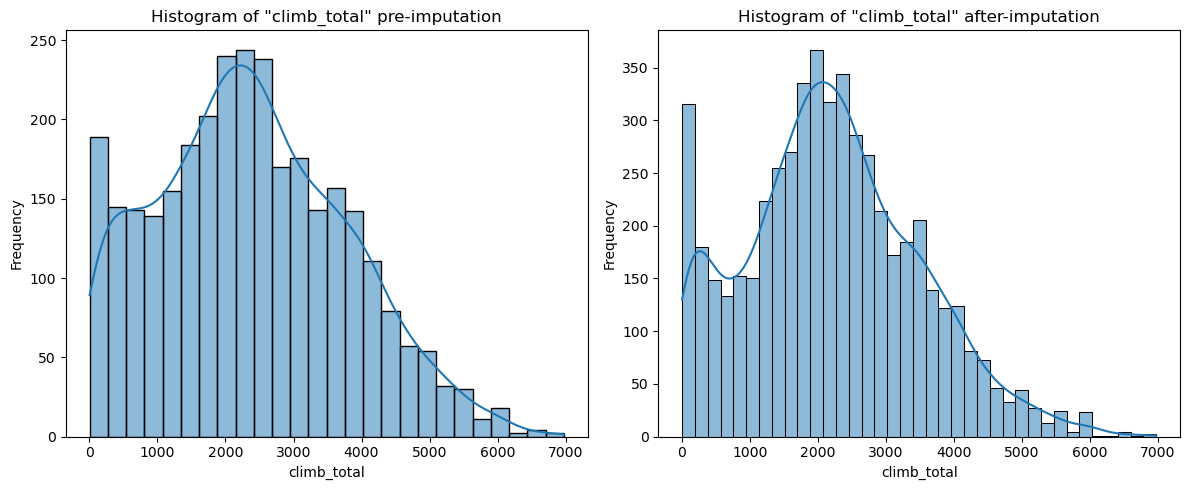

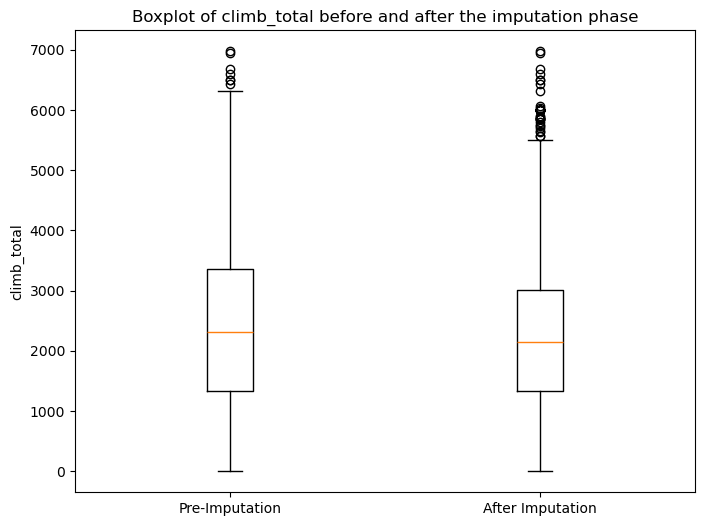

In [193]:
imputationComparison(races_data_pre_imputation, races_data, 'climb_total')

KNN Test with k=1


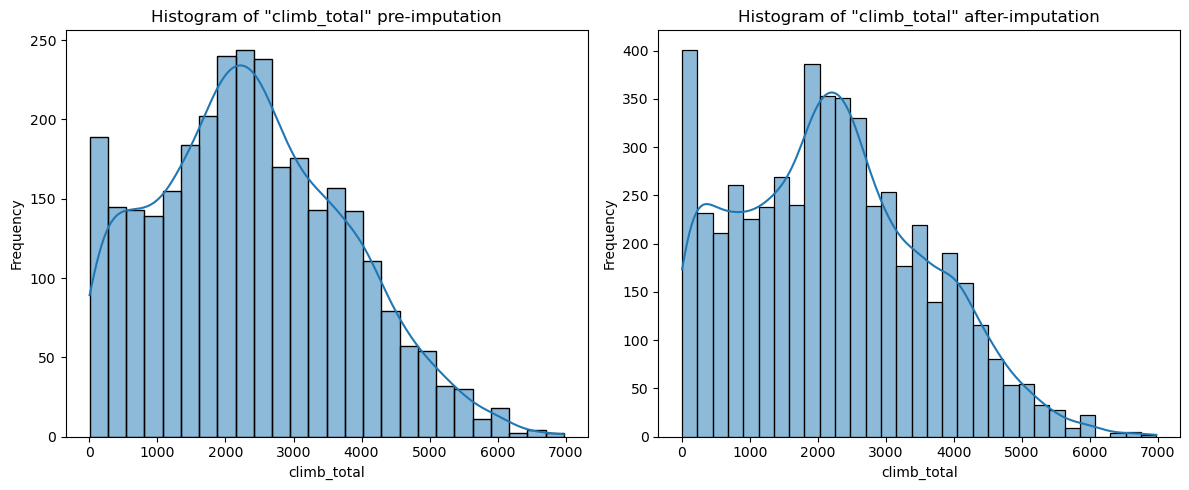

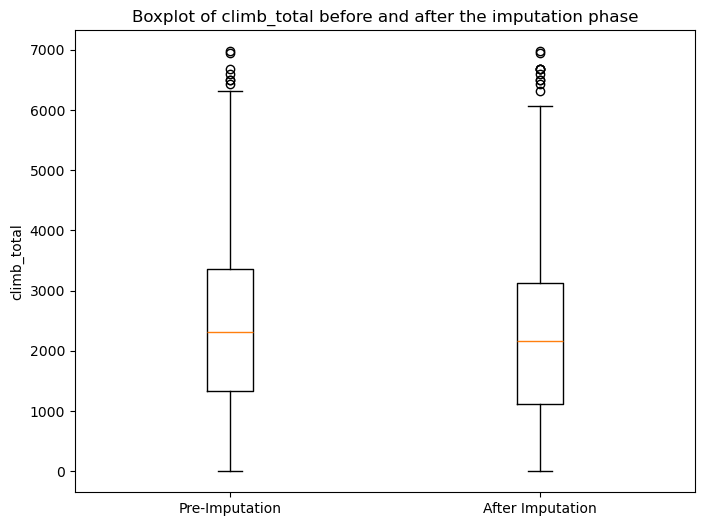

In [194]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(1, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=2


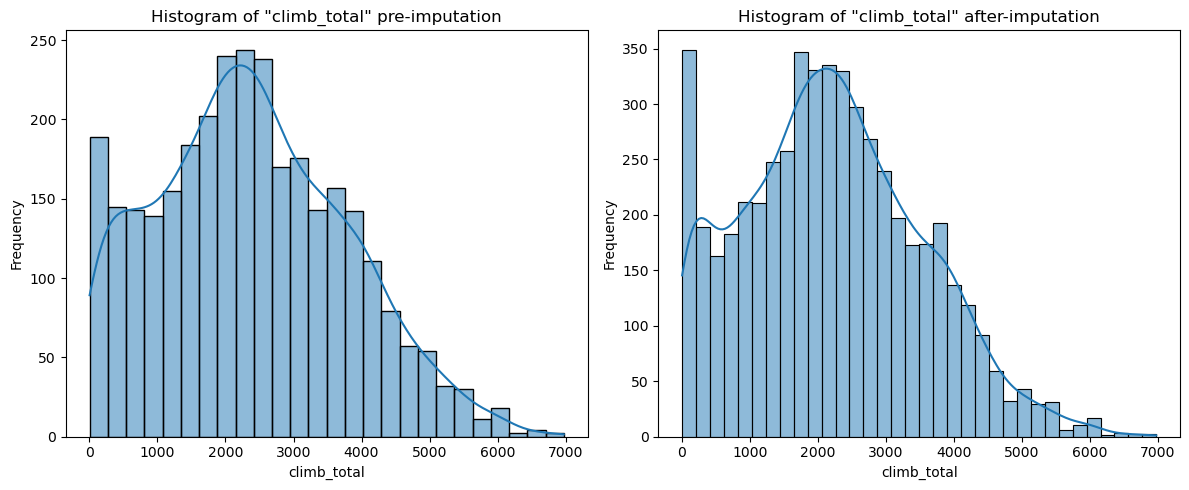

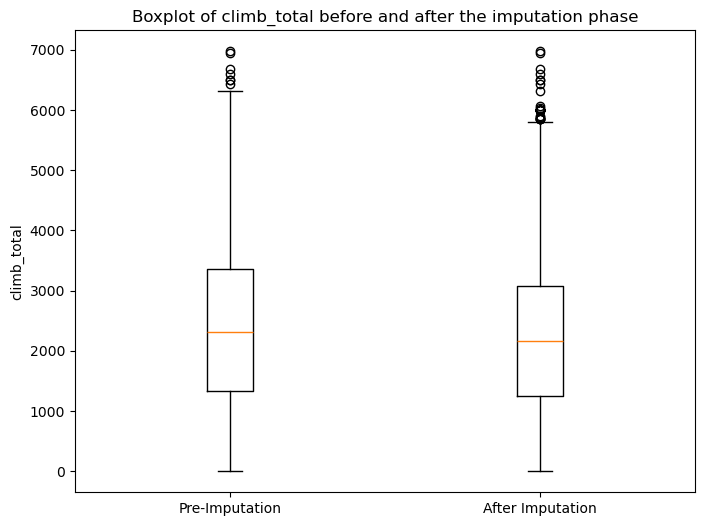

In [195]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(2, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=3


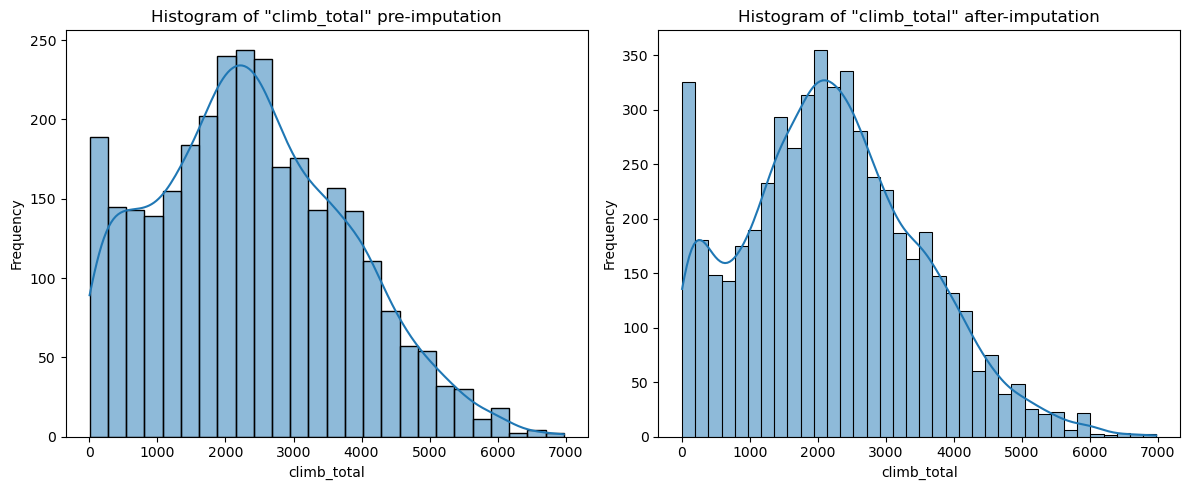

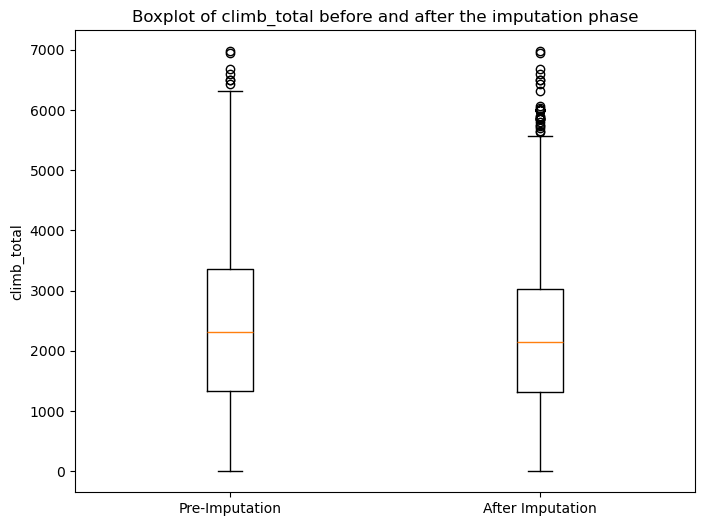

In [196]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(3, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=4


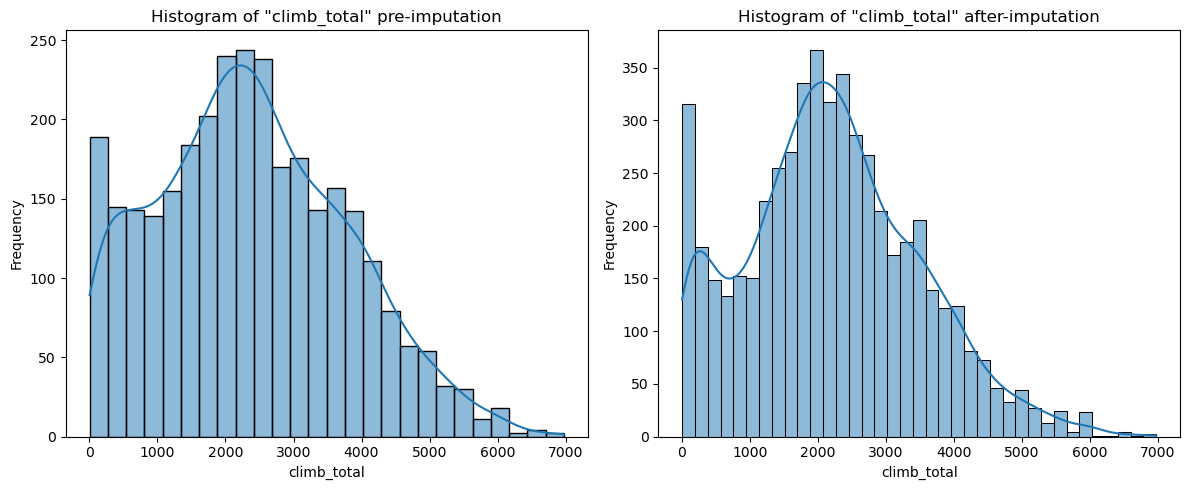

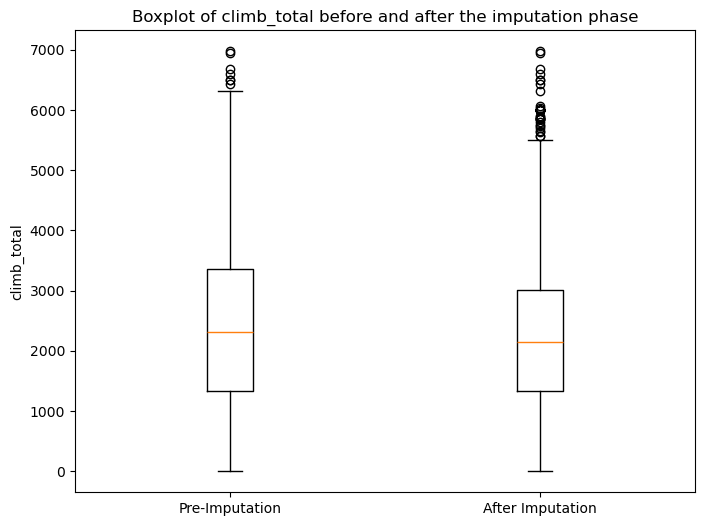

In [197]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(4, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=5


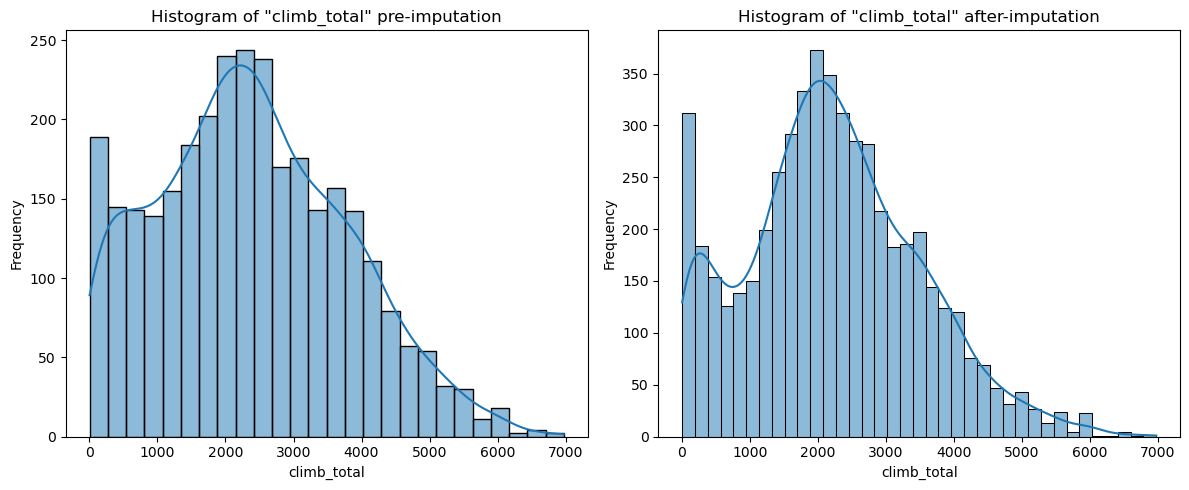

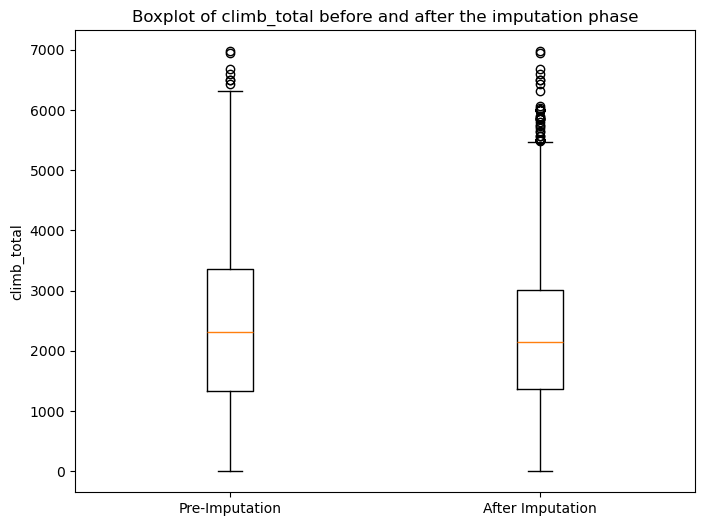

In [198]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(5, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=6


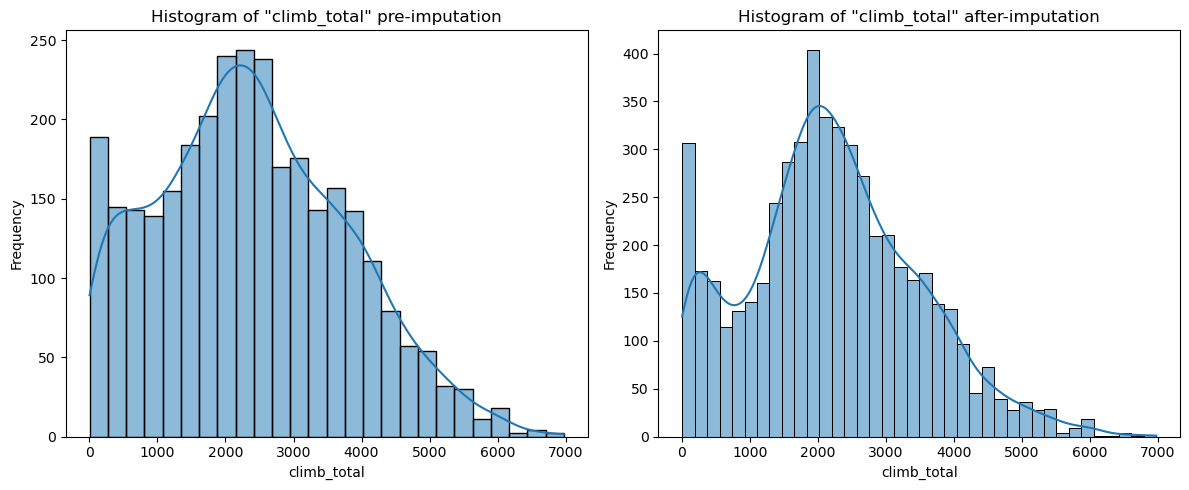

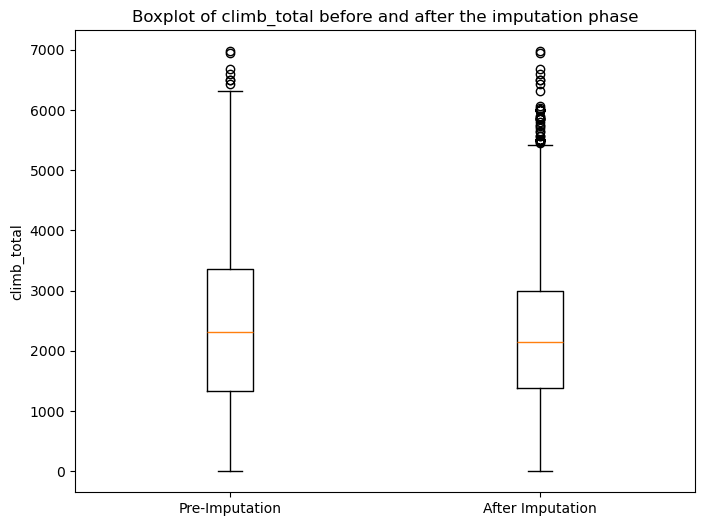

In [199]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(6, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=7


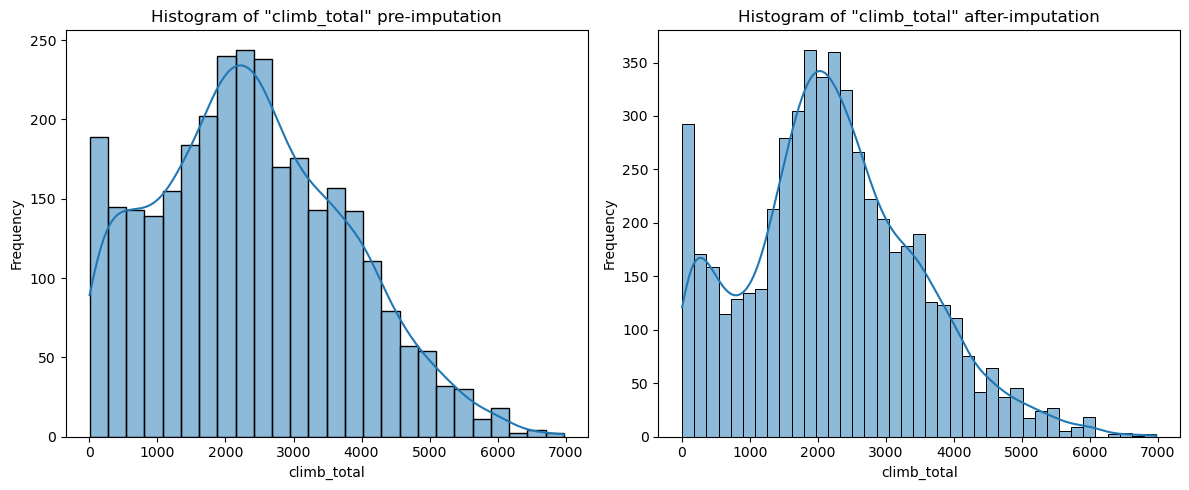

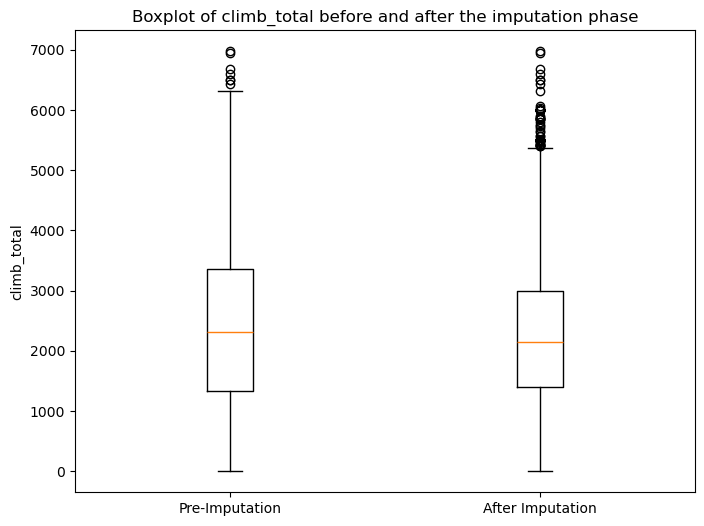

In [200]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(7, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=8


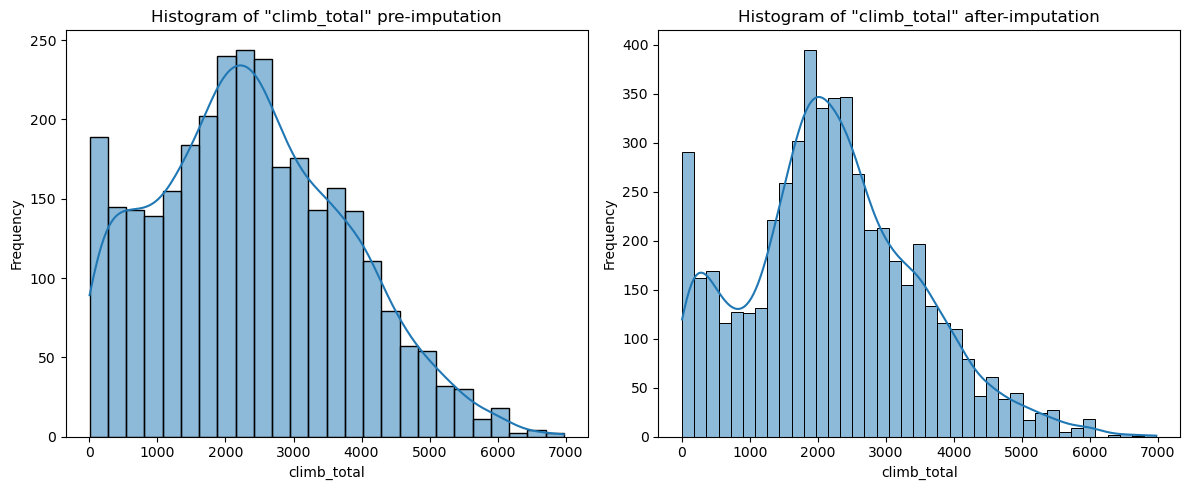

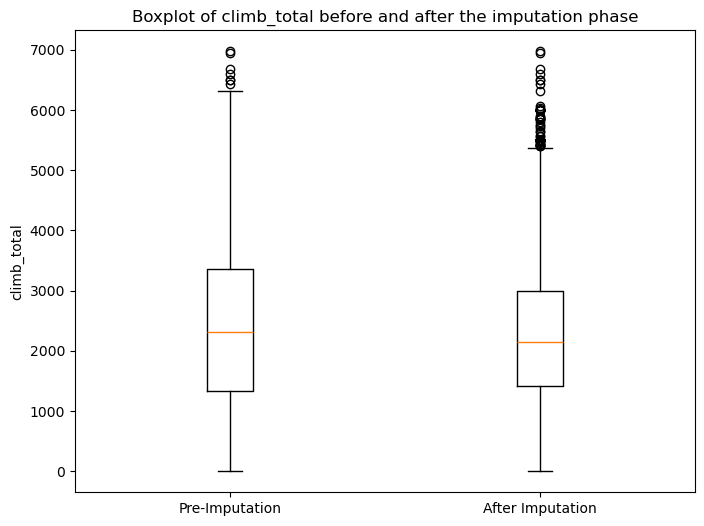

In [201]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(8, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=9


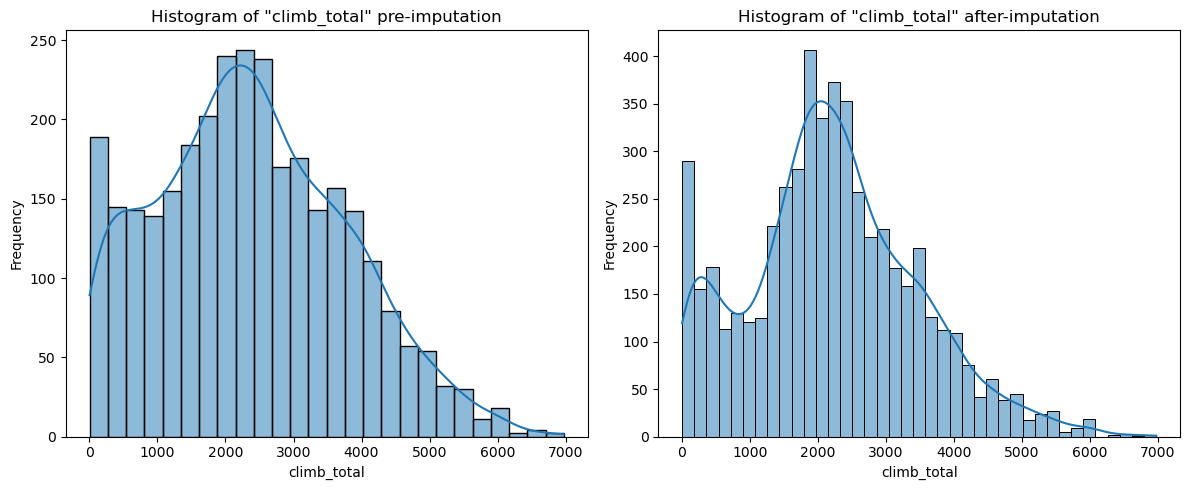

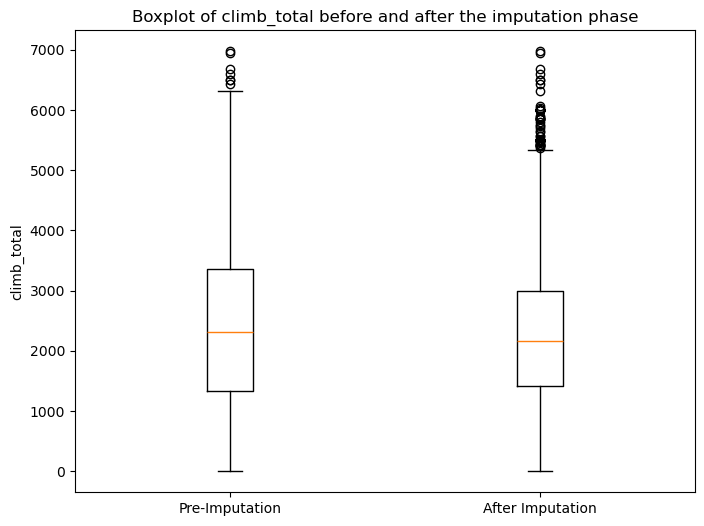

In [202]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(9, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

KNN Test with k=10


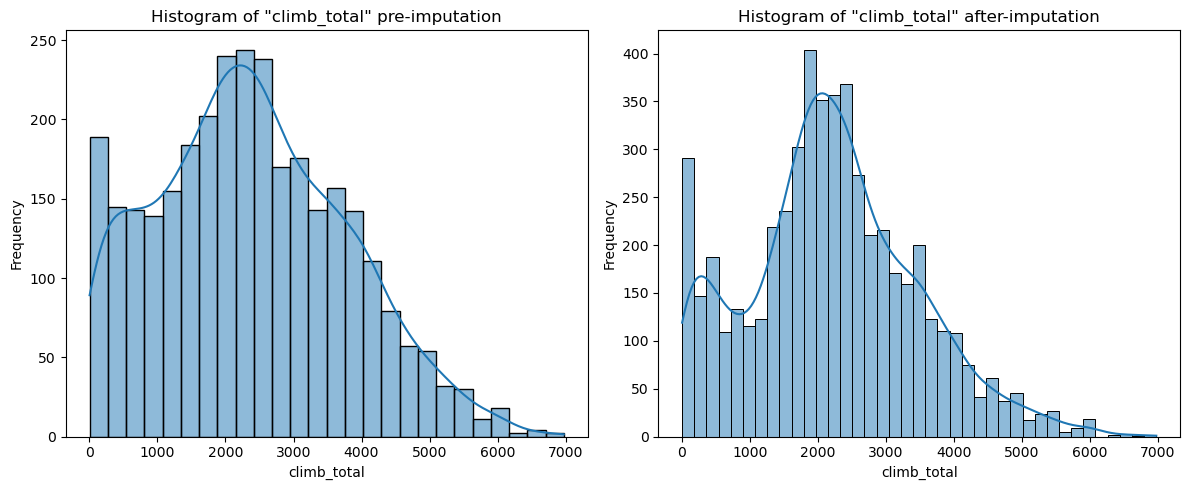

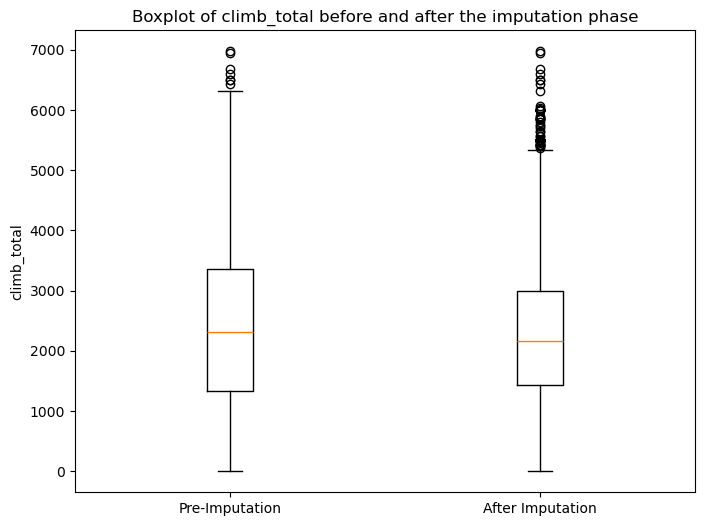

In [203]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(10, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

i migliori sembrano k=2 o 3

KNN Test with k=3


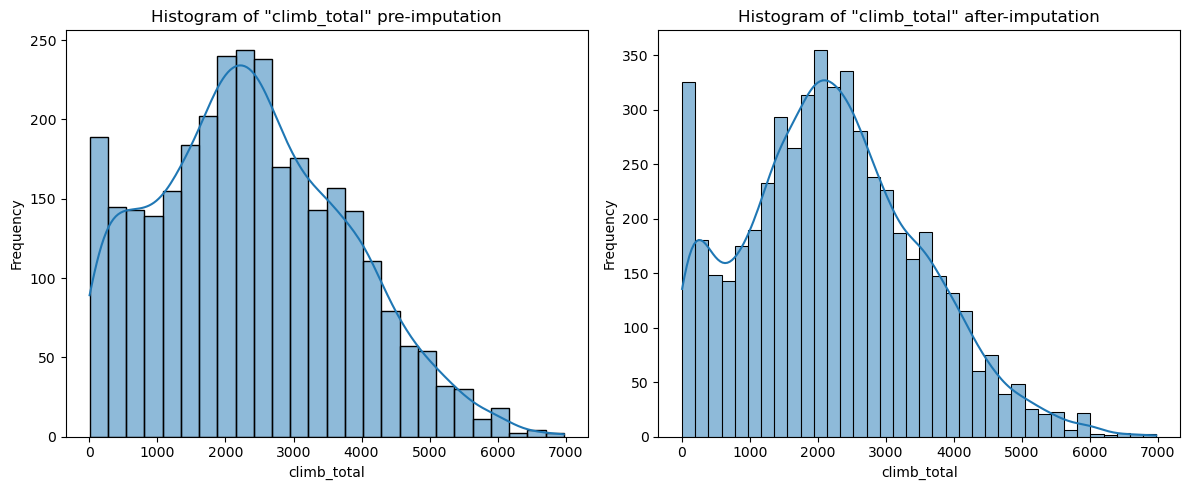

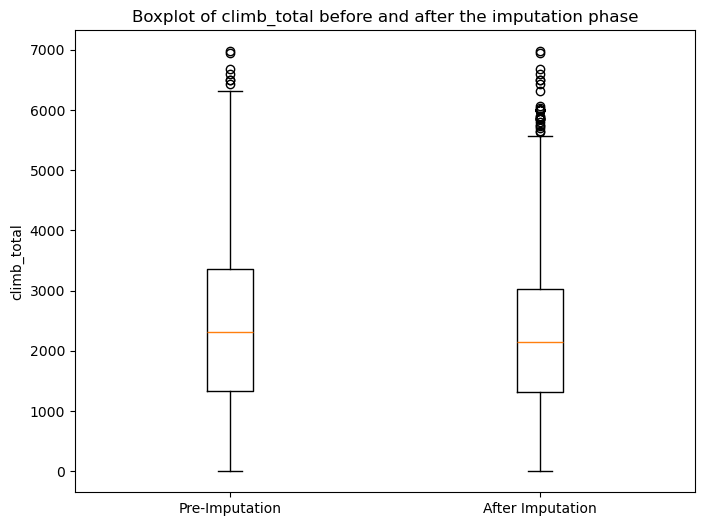

In [204]:
races_data=races_data_pre_imputation.copy()
try_knn_imputation(3, races_data_pre_imputation, races_data, columns_for_imputation, column_to_be_imputed)

In [205]:
races_data_pre_imputation['climb_total'].describe()

count    3067.000000
mean     2375.650473
std      1394.390513
min         2.000000
25%      1333.000000
50%      2307.000000
75%      3358.000000
max      6974.000000
Name: climb_total, dtype: float64

In [206]:
races_data['climb_total'].describe()

count    5281.000000
mean     2210.136711
std      1289.253856
min         2.000000
25%      1311.000000
50%      2154.000000
75%      3031.000000
max      6974.000000
Name: climb_total, dtype: float64

In [207]:
#update after imputation
races_data['climb/length'] = races_data['climb_total'] / races_data['length']

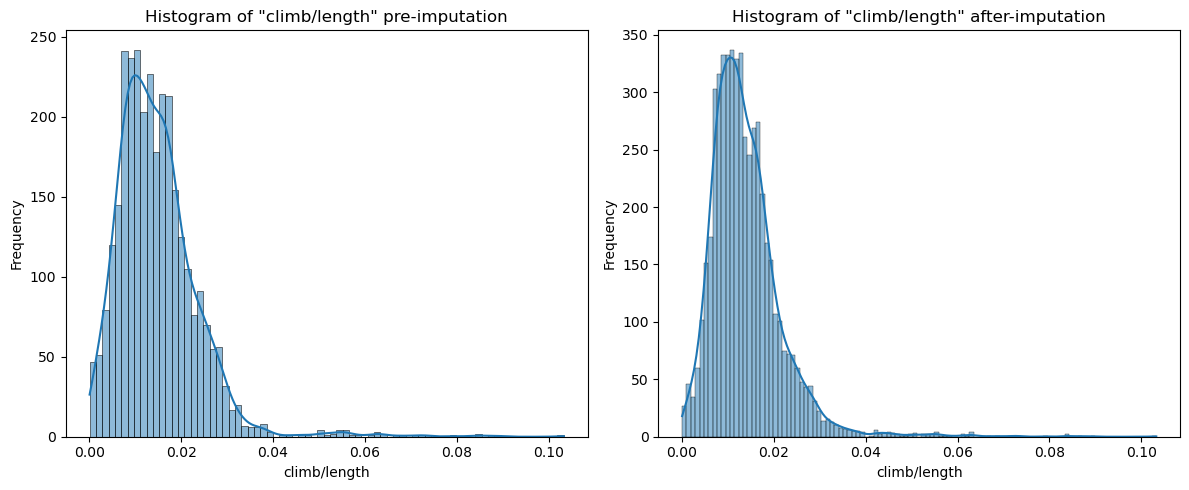

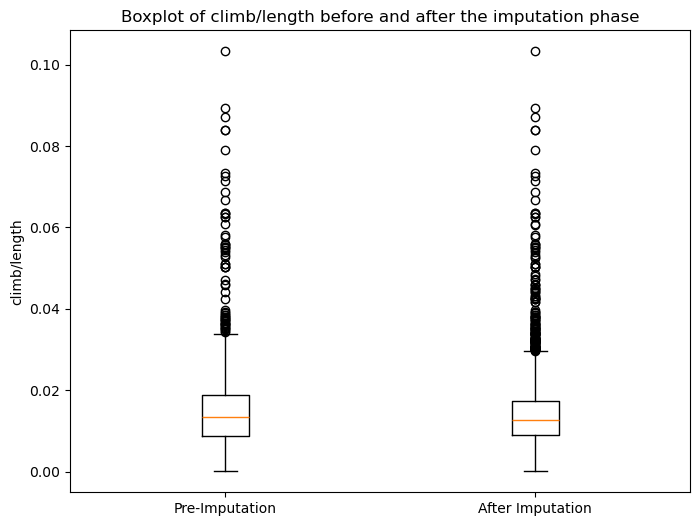

In [208]:
imputationComparison(races_data_pre_imputation, races_data, 'climb/length')

In [209]:
races_data_pre_imputation['climb/length'].describe()

count    3067.000000
mean        0.014813
std         0.009059
min         0.000069
25%         0.008803
50%         0.013438
75%         0.018845
max         0.103261
Name: climb/length, dtype: float64

In [210]:
races_data['climb/length'].describe()

count    5281.000000
mean        0.013984
std         0.007951
min         0.000069
25%         0.008902
50%         0.012612
75%         0.017214
max         0.103261
Name: climb/length, dtype: float64

. Creazione di una Soglia per Suddivisione
Descrizione: Se 'climb_total/length' mostra un pattern chiaro per cui valori più alti corrispondono a valori di 'profile' più elevati (o viceversa), puoi stabilire delle soglie per suddividere i dati in base a 'climb_total/length' e assegnare dei valori a 'profile' in base a tali range.
Implementazione:
Analizza la relazione tra 'climb_total/length' e 'profile' con un grafico di dispersione o una tabella di frequenze.
Identifica eventuali intervalli di 'climb_total/length' che corrispondono chiaramente a specifici valori di 'profile'.
Usa questi intervalli per assegnare i valori mancanti in 'profile'.
Esempio: Se noti che un 'climb_total/length' inferiore a 1000 corrisponde per la maggior parte a 'profile' = 1 e valori superiori a 5000 corrispondono a 'profile' = 5, puoi usare queste soglie per guidare l’imputazione.